# Doenças Cardíacas (Analise de dados DataSUS de 2024)

O dataset "dataSUS" contém dados de 2024, de todas as doenças do aparelho circulatório (CID-10 - abrangendo os códigos I00 a I99), de todos os estados do Brasil.



 ## Análise Exploratória dos dados

In [1]:
import sys
!{sys.executable} -m pip install scikit-learn pandas numpy matplotlib seaborn plotly nbformat

  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 45.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------------------------------------- -- 9.2/9.9 MB 43.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 38.5 MB/s eta 0:00:00
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------- ----------------------------- 10.0/36.5 MB 47.8 MB/s eta 0:00:01
   ----------------------- ---------------- 21.5/36.5 MB 50.3 MB/s eta 0:00:01
   ------------------------------------ --- 33.6/36.5 MB 52.0 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 44.7 MB/s eta 0:00:00


In [2]:
# ==========================================
# # Flamers Team 🔥 - Imports Oficiais
# ==========================================

# Analise dos dados
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Tratamento dos dados (Scikit-Learn)
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Modelos (Árvores e Ensembles)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# Métricas de Avaliação
from sklearn.metrics import (accuracy_score, roc_curve, roc_auc_score, 
                             classification_report, confusion_matrix)

# Visualização Interativa e Utilitários
import plotly.express as px  # Recomendado no lugar de plotly_express
import time
import os
from getpass import getpass

Lendo o conjunto de dados

In [7]:
# Carregar os dados
df = pd.read_csv('data/dataSUS.csv', sep=',', encoding='iso-8859-1')

# Visualizar as primeiras linhas
display(df.head())

,SEXO,IDADE,RACA_COR,INSTRU,MUNIC_RES,CAR_INT,COMPLEX,DIAS_PERM,UTI_MES_TO,MARCA_UTI,DIAG_PRINC,DIAG_SECUN,PROC_REA
0,1,85,3,0,120005,2,2,8,0,0,I500,0,303060212
1,3,73,3,0,120025,2,2,5,0,0,I64,0,303040149
2,1,70,3,0,120060,1,2,1,0,0,I219,0,301060088
3,1,81,4,0,120040,2,2,5,0,0,I638,0,303040149
4,1,48,4,0,120040,2,2,12,0,0,I64,0,303040149


## Informações sobre o conjunto de dados


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1249083 entries, 0 to 1249082
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   SEXO        1249083 non-null  int64 
 1   IDADE       1249083 non-null  int64 
 2   RACA_COR    1249083 non-null  int64 
 3   INSTRU      1249083 non-null  int64 
 4   MUNIC_RES   1249083 non-null  int64 
 5   CAR_INT     1249083 non-null  int64 
 6   COMPLEX     1249083 non-null  int64 
 7   DIAS_PERM   1249083 non-null  int64 
 8   UTI_MES_TO  1249083 non-null  int64 
 9   MARCA_UTI   1249083 non-null  int64 
 10  DIAG_PRINC  1249083 non-null  object
 11  DIAG_SECUN  1249083 non-null  int64 
 12  PROC_REA    1249083 non-null  int64 
dtypes: int64(12), object(1)
memory usage: 123.9+ MB


## 📊 Análise Estrutural do Dataset

Após a extração e carga dos dados do **DataSUS**, foi realizada uma inspeção técnica da estrutura do conjunto de dados utilizando o método `.info()`. Abaixo estão os metadados consolidados:

### 📑 Resumo da Composição
* **Total de Registros:** 1.249.083 entradas (de 0 a 1.249.082).
* **Total de Colunas:** 13 variáveis.
* **Qualidade da Amostra:** 100% de integridade (Não existem valores nulos/ausentes).
* **Uso de Memória:** ~123.9 MB.

### 🗂️ Dicionário Técnico de Variáveis

| # | Coluna | Contagem Non-Null | Dtype | Categoria |
|:---:|:---|:---:|:---:|:---:|
| 0 | **SEXO** | 1.249.083 | int64 | Demográfico |
| 1 | **IDADE** | 1.249.083 | int64 | Demográfico |
| 2 | **RACA_COR** | 1.249.083 | int64 | Demográfico |
| 3 | **INSTRU** | 1.249.083 | int64 | Socioeconómico |
| 4 | **MUNIC_RES** | 1.249.083 | int64 | Geográfico |
| 5 | **CAR_INT** | 1.249.083 | int64 | Administrativo |
| 6 | **COMPLEX** | 1.249.083 | int64 | Clínico |
| 7 | **DIAS_PERM** | 1.249.083 | int64 | Clínico |
| 8 | **UTI_MES_TO** | 1.249.083 | int64 | **Alvo (Target)** |
| 9 | **MARCA_UTI** | 1.249.083 | int64 | Clínico |
| 10 | **DIAG_PRINC** | 1.249.083 | object | Clínico (CID-10) |
| 11 | **DIAG_SECUN** | 1.249.083 | int64 | Clínico |
| 12 | **PROC_REA** | 1.249.083 | int64 | Procedimento |

---

### 🔍 Observações Técnicas para o Modelo 

1.  **Predomínio Numérico:** O dataset é composto majoritariamente por tipos `int64` (12 colunas). Isso indica que os dados já passaram por uma pré-codificação original do DataSUS, facilitando a aplicação de algoritmos de árvore como o `RandomForestClassifier`.
2.  **Variável de Texto:** A coluna `DIAG_PRINC` é a única do tipo `object`. Ela contém os códigos de diagnóstico (Ex: I10, I21). Para o modelo, será necessário aplicar o **LabelEncoder** ou **OneHotEncoder** nesta feature.
3.  **Variável Alvo:** A coluna `UTI_MES_TO` (ou `MARCA_UTI`) foi identificada como o alvo da nossa predição de risco para a saúde da mulher.
4.  **Limpeza:** Devido à ausência de valores nulos (*Non-Null Count* idêntico ao *RangeIndex*), não será necessário utilizar técnicas de imputação (como `SimpleImputer`), permitindo avançar diretamente para a normalização e treino.



# Tratemento de dados

### SEXO:
+ 1 = Masculino  
+ 3 = Feminino 

In [12]:
set(df.SEXO) # 1 = Masculino | 3 = Feminino.

{1, 3}

### RACA_COR:
+ 01 = Branca 
+ 02 = Preta 
+ 03 = Parda 
+ 04 = Amarela 
+ 05 = Indígena 
+ 99 = Sem informação

In [13]:
set(df.RACA_COR) # 01 = Branca | 02 = Preta | 03 = Parda | 04 = Amarela | 05 = Indígena | 99 = Sem informação.

{1, 2, 3, 4, 5, 99}

In [14]:
set(df.INSTRU) # Grau de instrução.
# Vai de 0 (Sem informação, Ignorado), 1(analfabeto), 2(Ensino Fundamental)), 3 (Ensino médio) e 4 (Ensino Superior).


{0, 1, 2, 3, 4}

In [15]:
set(df.CAR_INT) # Carater da internação  - 01 = Eletiva (agendada) | 02 = Urgência/Emergência

{1, 2}

In [16]:
set(df.COMPLEX) # 02 = Média Complexidade | 03 = Alta Complexidade.

{2, 3}

In [17]:
set(df.MARCA_UTI) # EXPLORAR

{0, 1, 74, 75, 76, 77, 78, 79, 81, 82, 83, 85, 86, 99}

Aplicamos set(dados.____) para quase todas as colunas, para analisar os tipos de dados.

In [18]:
df_sus = df

# Criamos uma lista vazia para guardar o resumo de cada coluna
info_colunas = []

for coluna in df_sus.columns:
    # Pega os valores únicos da coluna, removendo os nulos (dropna)
    valores_unicos = df_sus[coluna].dropna().unique()

    info_colunas.append({
        'Nome da Coluna': coluna,
        'Tipo de Dado': df_sus[coluna].dtype,
        'Qtd Valores Únicos': len(valores_unicos),
        # Pega apenas os 5 primeiros valores como amostra (o seu 'set' controlado)
        'Amostra de Valores': list(valores_unicos)[:5],
        'Qtd Nulos': df_sus[coluna].isnull().sum()
    })

# Transforma a lista em um DataFrame bonitão para visualizar
df_dicionario = pd.DataFrame(info_colunas)

# Exibe a tabela
display(df_dicionario)

,Nome da Coluna,Tipo de Dado,Qtd Valores Únicos,Amostra de Valores,Qtd Nulos
0,SEXO,int64,2,"[1, 3]",0
1,IDADE,int64,100,"[85, 73, 70, 81, 48]",0
2,RACA_COR,int64,6,"[3, 4, 5, 1, 2]",0
3,INSTRU,int64,5,"[0, 2, 3, 4, 1]",0
4,MUNIC_RES,int64,5344,"[120005, 120025, 120060, 120040, 130070]",0
5,CAR_INT,int64,2,"[2, 1]",0
6,COMPLEX,int64,2,"[2, 3]",0
7,DIAS_PERM,int64,187,"[8, 5, 1, 12, 11]",0
8,UTI_MES_TO,int64,109,"[0, 23, 39, 4, 6]",0
9,MARCA_UTI,int64,14,"[0, 75, 81, 78, 86]",0


## Resumo dos dados encontrado

| Coluna | Descrição | Valores / Legenda |
| :--- | :--- | :--- |
| **SEXO** | Gênero do paciente | `1` = Masculino <br> `3` = Feminino |
| **IDADE** | Idade do paciente | `0` a `99` anos |
| **RACA_COR** | Raça / Cor do paciente | `01` = Branca <br> `02` = Preta <br> `03` = Parda <br> `04` = Amarela <br> `05` = Indígena <br> `99` = Sem informação |
| **INSTRU** | Grau de Instrução | `0` = Sem informação / Ignorado <br> `1` = Analfabeto <br> `2` = Ensino Fundamental <br> `3` = Ensino Médio <br> `4` = Ensino Superior |
| **MUNIC_RES** | Município de residência | Códigos IBGE de 6 dígitos (5.344 municípios distintos no dataset) |
| **CAR_INT** | Caráter da Internação | `01` = Eletiva (agendada) <br> `02` = Urgência / Emergência |
| **COMPLEX** | Complexidade do Atendimento | `02` = Média Complexidade <br> `03` = Alta Complexidade |
| **DIAS_PERM** | Dias de Permanência Geral | `0` a `361` dias (Tempo total de internação) |
| **UTI_MES_TO** | Dias de Permanência na UTI | `0` a `274` dias |
| **MARCA_UTI** | Tipo de UTI utilizada | `0` = Não utilizou UTI <br> `74` = UTI Adulto Tipo II <br> `75` = UTI Adulto Tipo III <br> `76 a 79` = UTIs Pediátricas/Especializadas <br> `81 a 86` = UTIs Neonatais / Coronarianas <br> `99` = Ignorado (Não tem registrado no BD)|
| **DIAG_PRINC** | Diagnóstico Principal (CID-10) | 455 tipos de códigos iniciados com "I" (Doenças do aparelho circulatório) |
| **DIAG_SECUN** | Diagnóstico Secundário | Código secundário (se houver). Neste dataset possui 1 tipo registrado (`0` = sem diag. secundário) |
| **PROC_REA** | Procedimento Realizado | Código de 10 dígitos da Tabela SIGTAP do SUS indicando a cirurgia/tratamento exato. |

# EXCLUIR COLUNAS COM DADOS IRRELEVANTES

###Exclusão das colunas MUNC_RES, DIAG_SECUN, INSTRU

Excluir as colunas MUNC_RES porque para nós o importante são os dados gerais do brasil todo.

Excluir a coluna DIAG_SECUN na qual todos os dados são 0, ou seja, sem diagnóstico secundário.

Excluir a coluna INSTRU porque aparentemente os dados não foram devidamente coletados, conforme o gráfico abaixo. Vemos que as categorias são muito discrepantes, dominando a categoria "0" que é "Sem Informação"

In [ ]:
contagem_absoluta = df_sus['INSTRU'].value_counts().sort_index()
display(contagem_absoluta)

print("\nContagem em Porcentagem (%):")

contagem_percentual = (df_sus['INSTRU'].value_counts(normalize=True).sort_index() * 100).round(2)
display(contagem_percentual)

,count
INSTRU,
0,1249043
1,3
2,15
3,19
4,3



Contagem em Porcentagem (%):


,proportion
INSTRU,
0,100.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
df_sus.drop(columns=['DIAG_SECUN', 'MUNIC_RES', 'INSTRU'], inplace=True)

array([[<Axes: title={'center': 'SEXO'}>,
        <Axes: title={'center': 'IDADE'}>,
        <Axes: title={'center': 'RACA_COR'}>],
       [<Axes: title={'center': 'CAR_INT'}>,
        <Axes: title={'center': 'COMPLEX'}>,
        <Axes: title={'center': 'DIAS_PERM'}>],
       [<Axes: title={'center': 'UTI_MES_TO'}>,
        <Axes: title={'center': 'MARCA_UTI'}>,
        <Axes: title={'center': 'PROC_REA'}>]], dtype=object)

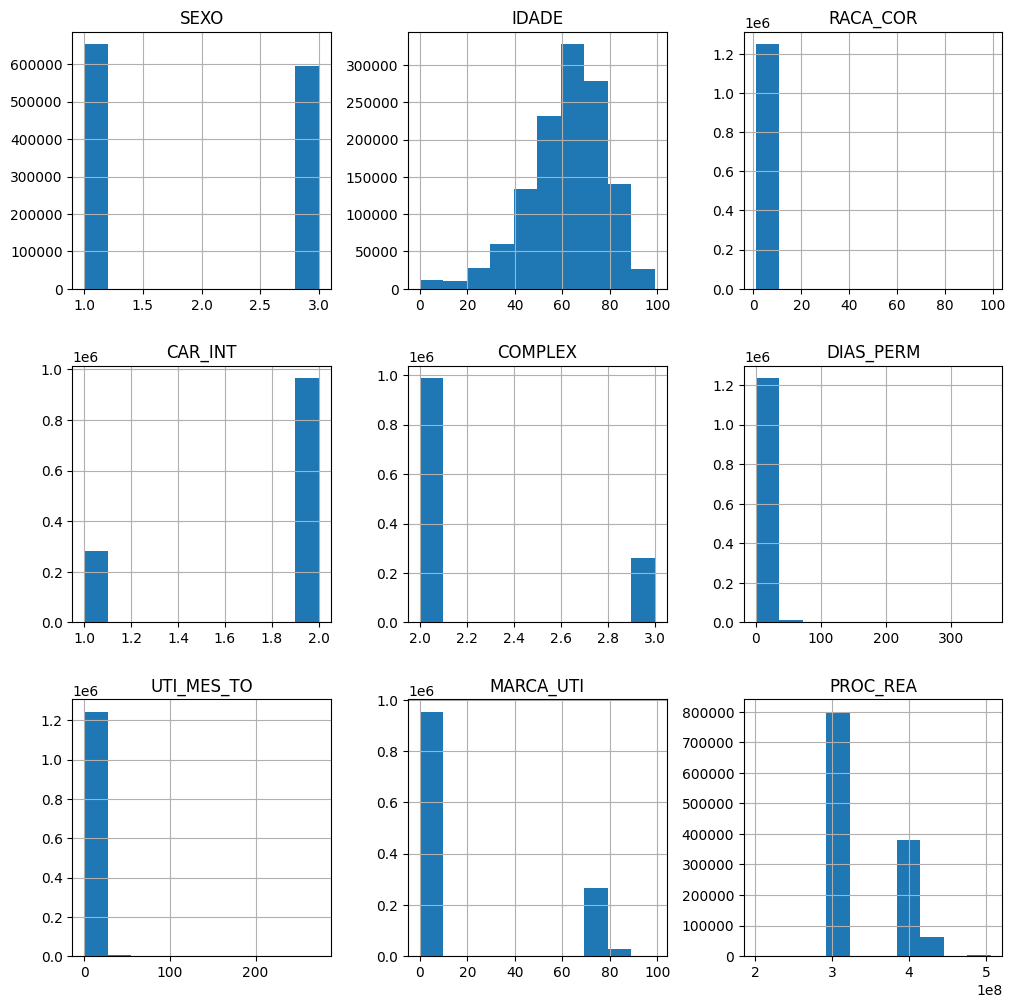

In [ ]:
df_sus.hist(figsize=(12,12))


# TRATAMENTO DE DADOS DAS COLUNAS RELEVANTES

## Coluna PROC_REA (Procedimento realizado)

### Tratamento dos dados constantes em PROC_REA (Procedimento realizado)
 Tendo em vista que a feature PROC_REA (Procedimento realizado) tem mais de 767 tipos, faremos o agrupamento em 8 subcategorias conforme consta no Ministério da Saúde:

Categorias oficiais do Ministério da Saúde:

    01: Ações de promoção e prevenção em saúde

    02: Procedimentos com finalidade diagnóstica (Exames)

    03: Procedimentos clínicos (Terapias, hidratação, acompanhamento)

    04: Procedimentos cirúrgicos

    05: Transplantes de órgãos, tecidos e células

    06: Medicamentos

    07: Órteses, Próteses e Materiais Especiais (OPM - ex: Marca-passo)

    08: Ações complementares

In [ ]:
print("Extraindo o Código Macro dos procedimentos (SIGTAP)...")

# encadeamento: Converte para texto -> Preenche os zeros -> Corta os 2 primeiros.
df_sus['GRUPO_PROC_COD'] = df_sus['PROC_REA'].astype(str).str.zfill(10).str[:2]

# Verificando o resultado de forma limpa e direta
print("\nDistribuição dos Códigos Macro:")
display(df_sus['GRUPO_PROC_COD'].value_counts())


Extraindo o Código Macro dos procedimentos (SIGTAP)...

Distribuição dos Códigos Macro:


,count
GRUPO_PROC_COD,
03,800461
04,442970
05,4841
02,811


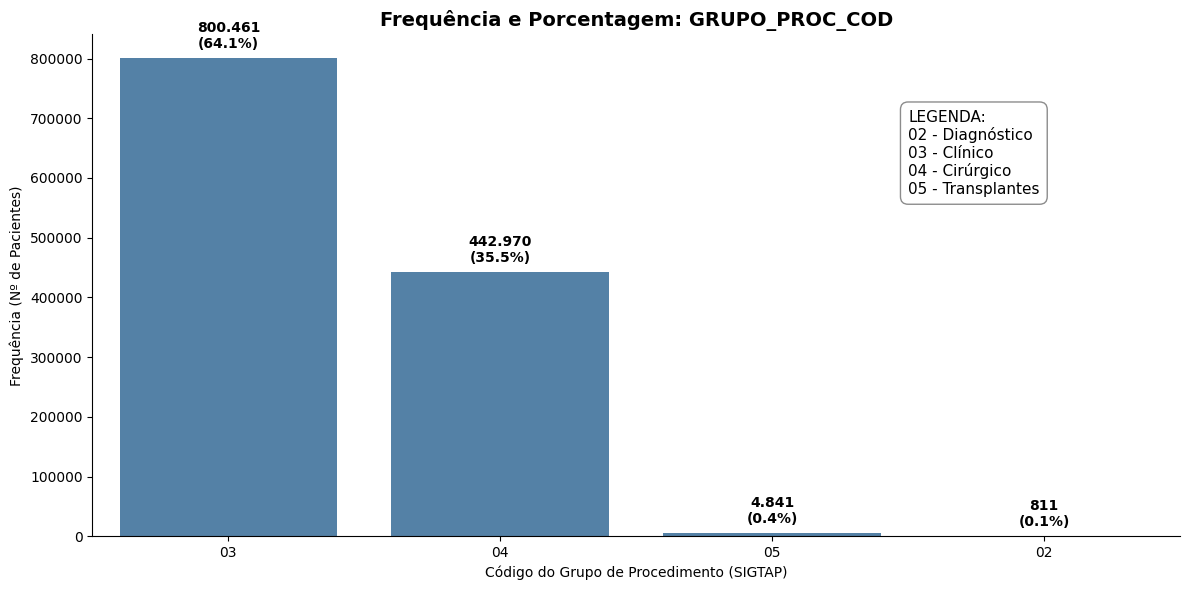

In [ ]:
coluna = 'GRUPO_PROC_COD'

plt.figure(figsize=(12, 6))

ordem = df_sus[coluna].value_counts().index

ax = sns.countplot(data=df_sus, x=coluna, order=ordem, color='steelblue')

plt.title(f'Frequência e Porcentagem: {coluna}', fontweight='bold', fontsize=14)
plt.ylabel('Frequência (Nº de Pacientes)')
plt.xlabel('Código do Grupo de Procedimento (SIGTAP)')

total_pacientes = len(df_sus[coluna].dropna())

for p in ax.patches:
    altura = p.get_height()
    porcentagem = (altura / total_pacientes) * 100

    texto = f'{int(altura):,}\n({porcentagem:.1f}%)'.replace(',', '.')

    if str(altura) != 'nan' and altura > 0:
        ax.annotate(texto,
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

plt.xticks(rotation=0)

# legenda
texto_legenda = (
    "LEGENDA:\n"
    "02 - Diagnóstico\n"
    "03 - Clínico\n"
    "04 - Cirúrgico\n"
    "05 - Transplantes"
)

plt.text(0.75, 0.85, texto_legenda, transform=ax.transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))
sns.despine()
plt.tight_layout()
plt.show()

AGORA UMA ANÁLISE MAIS ESPECÍFICA SOBRE O GRUPO 02 - DE GRUPO_PROC_COD

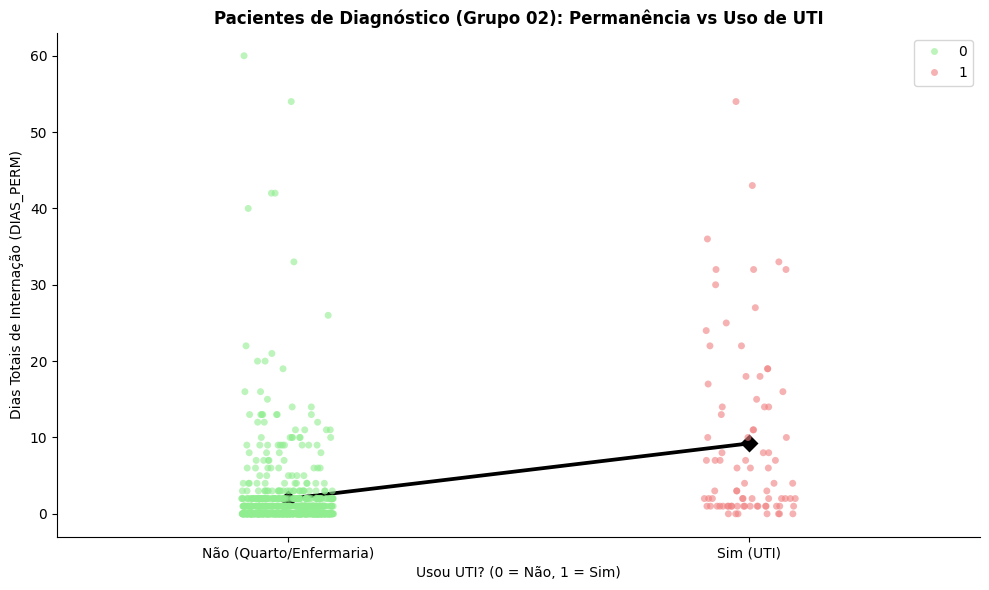

In [ ]:

df_diag = df_sus[df_sus['GRUPO_PROC_COD'] == '02'].copy()

df_diag['ALVO_UTI'] = (df_diag['UTI_MES_TO'] > 0).astype(int)


plt.figure(figsize=(10, 6))

sns.stripplot(data=df_diag,
              x='ALVO_UTI',
              y='DIAS_PERM',
              hue='ALVO_UTI',
              palette={0: 'lightgreen', 1: 'lightcoral'},
              jitter=True,
              alpha=0.6,
              size=5)

plt.title('Pacientes de Diagnóstico (Grupo 02): Permanência vs Uso de UTI', fontweight='bold')
plt.xlabel('Usou UTI? (0 = Não, 1 = Sim)')
plt.ylabel('Dias Totais de Internação (DIAS_PERM)')
plt.xticks([0, 1], ['Não (Quarto/Enfermaria)', 'Sim (UTI)'])

# média
sns.pointplot(data=df_diag, x='ALVO_UTI', y='DIAS_PERM', color='black', errorbar=None, markers='D')

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# Contagem lógica com base na variável df_diag (Grupo 02)
bate_e_volta = (df_diag['DIAS_PERM'] == 0).sum()
internou_mesmo = (df_diag['DIAS_PERM'] > 0).sum()

print("--- PACIENTES DE DIAGNÓSTICO (GRUPO 02) ---")
print(f"Ficaram 0 dias (Bate e volta): {bate_e_volta}")
print(f"Ficaram 1 dia ou mais internados: {internou_mesmo}")

--- PACIENTES DE DIAGNÓSTICO (GRUPO 02) ---
Ficaram 0 dias (Bate e volta): 364
Ficaram 1 dia ou mais internados: 447


In [ ]:
# Contagem lógica com base na variável df_diag (Grupo 02)
bate_e_volta = (df_diag['UTI_MES_TO'] == 0).sum()
internou_mesmo = (df_diag['UTI_MES_TO'] > 0).sum()

print("--- PACIENTES DE DIAGNÓSTICO (GRUPO 02) ---")
print(f"Ficaram 0 dias (Bate e volta): {bate_e_volta}")
print(f"Ficaram 1 dia ou mais internados: {internou_mesmo}")

--- PACIENTES DE DIAGNÓSTICO (GRUPO 02) ---
Ficaram 0 dias (Bate e volta): 726
Ficaram 1 dia ou mais internados: 85


**CONSTATAÇÕES GERAIS SOBRE A COLUNA PROC_REA:**

> Descobrimos que **64%** das internações por doenças isquêmicas do coração no SUS são **resolvidas clinicamente (sem cirurgia)**.

> As **cirurgias invasivas** (Grupo 04, como Angioplastias e Colocação de Stent) representam cerca de **35%** dos casos.

> **Transplantes** de coração (05) em caráter de urgência por infarto representam uma taxa raríssima de 0.4%.

> A categoria "**Diagnóstico**" é uma categoria rara, na qual boa parte dos pacientes ficaram internados, seja por causa de procedimentos eletivos, e uma baixa proporção ficou na UTI.

## Coluna DIAG_PRINC (Diagnóstico Principal)


 Tendo em vista que a feature DIAG_PRINC tem mais de 455 tipos, faremos o agrupamento em 11 subcategorias conforme consta na OMS.


| Código do Bloco | Descrição Clínica Oficial (OMS) |
| :--- | :--- |
| **`00-02`** | Febre Reumática Aguda |
| **`05-09`** | Doenças Cardíacas Reumáticas Crônicas |
| **`10-15`** | Doenças Hipertensivas |
| **`20-25`** | Doenças Isquêmicas (Ex: Infarto do Miocárdio) |
| **`26-28`** | Doenças Cardiopulmonares |
| **`30-52`** | Outras Doenças do Coração (Ex: Insuficiência Cardíaca) |
| **`60-69`** | Doenças Cerebrovasculares (Ex: AVC - Acidente Vascular Cerebral) |
| **`70-79`** | Doenças das Artérias e Capilares |
| **`80-89`** | Doenças das Veias e Vasos Linfáticos |
| **`95-99`** | Outros Transtornos Circulatórios |
| **`Invalido`**| Outros Capítulos ou Código Inválido |

### Tratament dos dados constantes em DIAG_PRINC (Diagnóstico Principal)

Fazer o agrupamento do DIAG_PRINC em 11 subcategorias conforme consta na OMS.

In [ ]:

df_sus['CID_3_DIGITOS'] = df_sus['DIAG_PRINC'].astype(str).str.strip().str[:3]

def mapear_bloco_oms(cid):
    cid = str(cid).strip()

    if not cid.startswith('I') or len(cid) < 3:
        return 'Outros_ou_Invalido'

    try:
        num = int(cid[1:3])
    except ValueError:
        return 'Outros_ou_Invalido'

    # Classificação
    if 0 <= num <= 2:
        return '00-02'
    elif 5 <= num <= 9:
        return '05-09'
    elif 10 <= num <= 15:
        return '10-15'
    elif 20 <= num <= 25:
        return '20-25'
    elif 26 <= num <= 28:
        return '26-28'
    elif 30 <= num <= 52:
        return '30-52'
    elif 60 <= num <= 69:
        return '60-69'
    elif 70 <= num <= 79:
        return '70-79'
    elif 80 <= num <= 89:
        return '80-89'
    elif 95 <= num <= 99:
        return '95-99'
    else:
        return 'Invalido'

df_sus['BLOCO_CLINICO_OMS'] = df_sus['DIAG_PRINC'].apply(mapear_bloco_oms)

display(df_sus['BLOCO_CLINICO_OMS'].value_counts())

,count
BLOCO_CLINICO_OMS,
20-25,316460
30-52,304322
60-69,260953
80-89,187773
70-79,103683
10-15,49505
26-28,15492
05-09,8297
95-99,1380


Análise do Bloco Clínico (10 tipos no total registrados)

## Coluna target UTI_MES_TO

### Tratamento da coluna TARGET

Criando a coluna TARGET SIMPLIFICADA (0 ou 1) a partir da coluna UTI_MES_TO

In [ ]:
df_sus['ALVO_UTI'] = (df_sus['UTI_MES_TO'] > 0).astype(int)

distribuicao = df_sus['ALVO_UTI'].value_counts()
display(distribuicao)


,count
ALVO_UTI,
0,951021
1,298062


/tmp/ipykernel_52193/187062246.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_sus, x=coluna, order=ordem, palette='viridis')


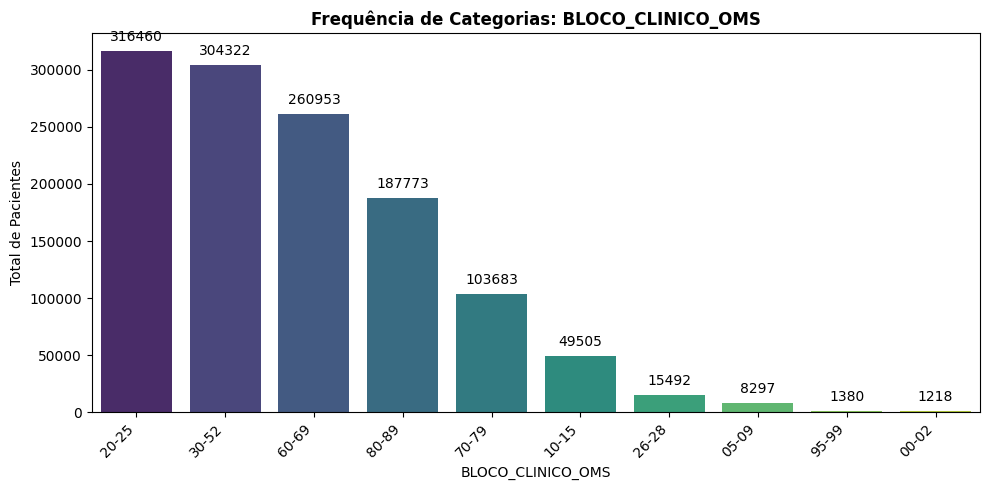

In [ ]:
coluna = 'BLOCO_CLINICO_OMS'

ordem = df_sus[coluna].value_counts().iloc[:15].index

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_sus, x=coluna, order=ordem, palette='viridis')
plt.title(f'Frequência de Categorias: {coluna}', fontweight='bold')
plt.ylabel('Total de Pacientes')
plt.xticks(rotation=45, ha='right')

#  números exatos em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

- 00-02 	Febre Reumática Aguda
- 05-09 	Doenças Cardíacas Reumáticas Crônicas
- 10-15 	Doenças Hipertensivas
- 20-25 	Doenças Isquêmicas (Ex: Infarto do Miocárdio)
- 26-28 	Doenças Cardiopulmonares
- 30-52 	Outras Doenças do Coração (Ex: Insuficiência Cardíaca)
- 60-69 	Doenças Cerebrovasculares (Ex: AVC - Acidente Vascular Cerebral)
- 70-79 	Doenças das Artérias e Capilares
- 80-89 	Doenças das Veias e Vasos Linfáticos
- 95-99 	Outros Transtornos Circulatórios

/tmp/ipykernel_52193/4224153938.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


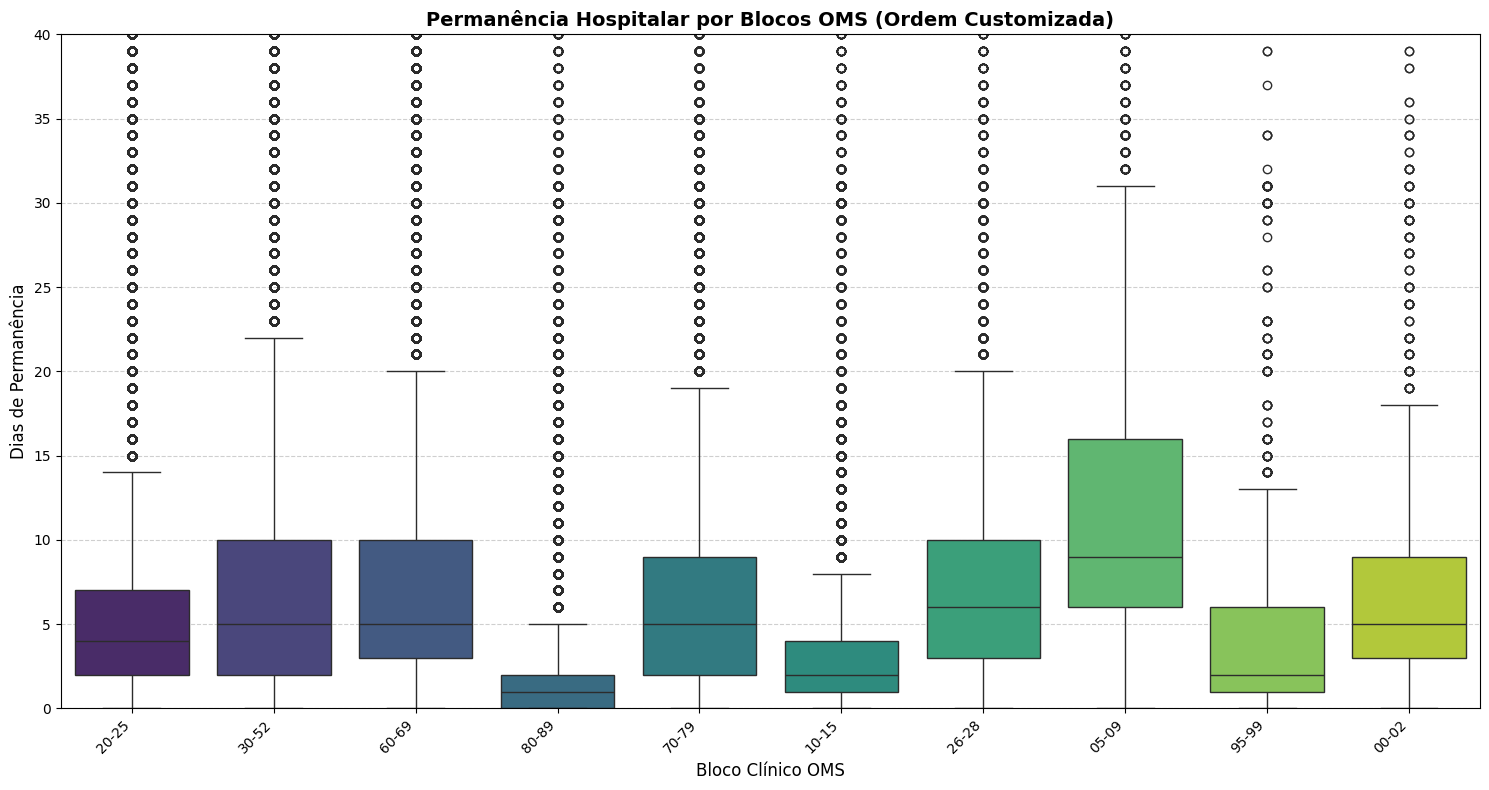

In [ ]:

ordem_customizada = [
    "20-25", "30-52", "60-69", "80-89", "70-79",
    "10-15", "26-28", "05-09", "95-99", "00-02"
]

plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df_sus,
    x='BLOCO_CLINICO_OMS',
    y='DIAS_PERM',
    order=ordem_customizada,
    palette='viridis'
)

plt.title('Permanência Hospitalar por Blocos OMS (Ordem Customizada)', fontweight='bold', fontsize=14)
plt.xlabel('Bloco Clínico OMS', fontsize=12)
plt.ylabel('Dias de Permanência', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.ylim(0, 40)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

- 00-02 	Febre Reumática Aguda
- 05-09 	Doenças Cardíacas Reumáticas Crônicas
- 10-15 	Doenças Hipertensivas
- 20-25 	Doenças Isquêmicas (Ex: Infarto do Miocárdio)
- 26-28 	Doenças Cardiopulmonares
- 30-52 	Outras Doenças do Coração (Ex: Insuficiência Cardíaca)
- 60-69 	Doenças Cerebrovasculares (Ex: AVC - Acidente Vascular Cerebral)
- 70-79 	Doenças das Artérias e Capilares
- 80-89 	Doenças das Veias e Vasos Linfáticos
- 95-99 	Outros Transtornos Circulatórios

Gerando gráfico de volume absoluto (sem filtros)...


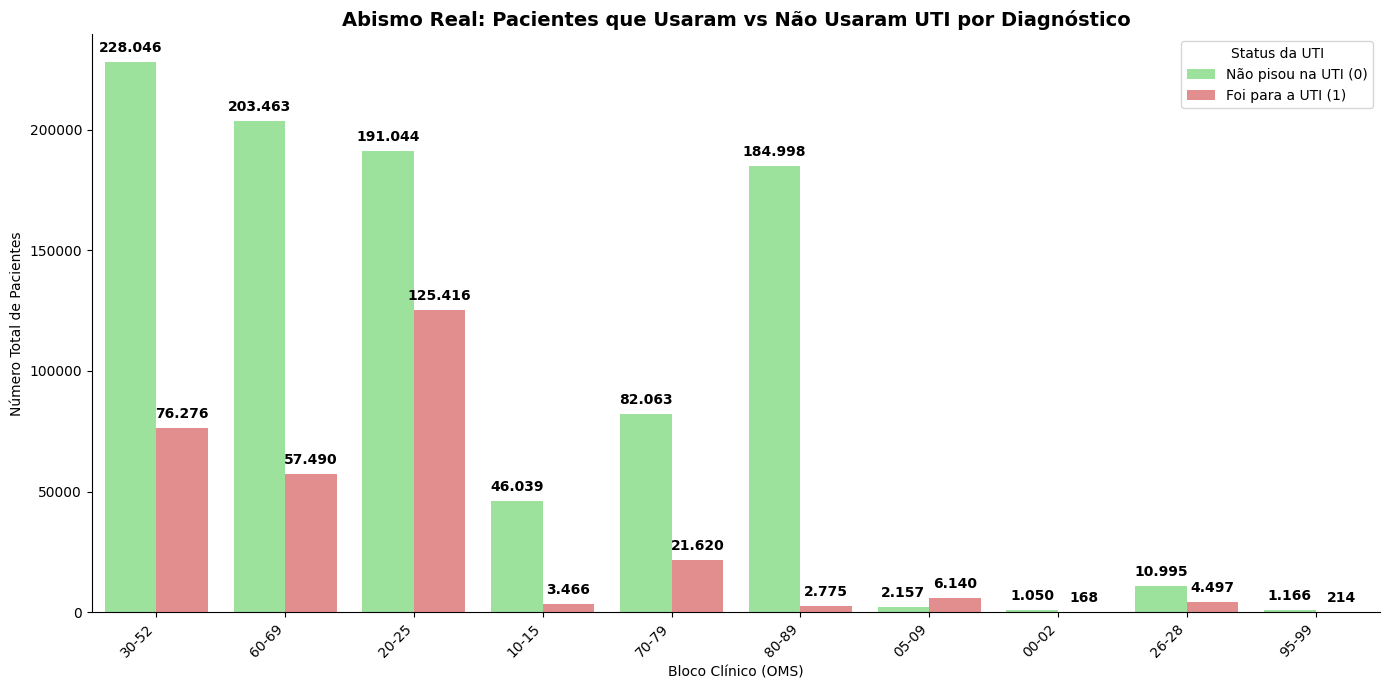

In [ ]:
print("Gerando gráfico de volume absoluto (sem filtros)...")

plt.figure(figsize=(14, 7))

# Passamos a base inteira e pedimos para o Seaborn criar duas barras para cada Bloco:
# Uma para ALVO_UTI = 0 (Não usou) e outra para ALVO_UTI = 1 (Usou)
ax = sns.countplot(data=df_sus,
                   x='BLOCO_CLINICO_OMS',
                   hue='ALVO_UTI',
                   palette={0: 'lightgreen', 1: 'lightcoral'})

plt.title('Abismo Real: Pacientes que Usaram vs Não Usaram UTI por Diagnóstico', fontweight='bold', fontsize=14)
plt.ylabel('Número Total de Pacientes')
plt.xlabel('Bloco Clínico (OMS)')

# Renomeando a legenda para ficar legível para a diretoria do hospital
legend = plt.legend(title='Status da UTI', loc='upper right')
legend.texts[0].set_text('Não pisou na UTI (0)')
legend.texts[1].set_text('Foi para a UTI (1)')

# O laço para escrever o número exato de pessoas em cima de cada arranha-céu
for p in ax.patches:
    altura = p.get_height()
    # O if abaixo evita que o Python tente escrever números em barras vazias
    if str(altura) != 'nan' and altura > 0:
        ax.annotate(f'{int(altura):,}'.replace(',', '.'),
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points', rotation=0)

plt.xticks(rotation=45, ha='right')
sns.despine() # Remove as bordas do topo e da direita
plt.tight_layout()
plt.show()

- 00-02 	Febre Reumática Aguda
- 05-09 	Doenças Cardíacas Reumáticas Crônicas
- 10-15 	Doenças Hipertensivas
- 20-25 	Doenças Isquêmicas (Ex: Infarto do Miocárdio)
- 26-28 	Doenças Cardiopulmonares
- 30-52 	Outras Doenças do Coração (Ex: Insuficiência Cardíaca)
- 60-69 	Doenças Cerebrovasculares (Ex: AVC - Acidente Vascular Cerebral)
- 70-79 	Doenças das Artérias e Capilares
- 80-89 	Doenças das Veias e Vasos Linfáticos
- 95-99 	Outros Transtornos Circulatórios

## Coluna SEXO

In [ ]:
df_sus['SEXO'].value_counts()

,count
SEXO,
1,653185
3,595898


/tmp/ipykernel_52193/2350257181.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_sus, x=coluna, order=ordem, palette='viridis')


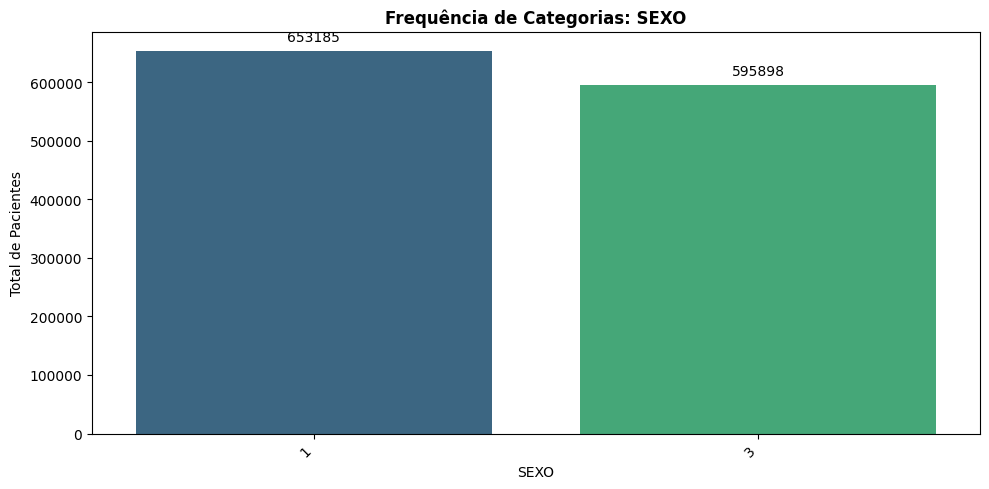

In [ ]:
coluna = 'SEXO'

ordem = df_sus[coluna].value_counts().iloc[:15].index

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_sus, x=coluna, order=ordem, palette='viridis')
plt.title(f'Frequência de Categorias: {coluna}', fontweight='bold')
plt.ylabel('Total de Pacientes')
plt.xticks(rotation=45, ha='right')


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

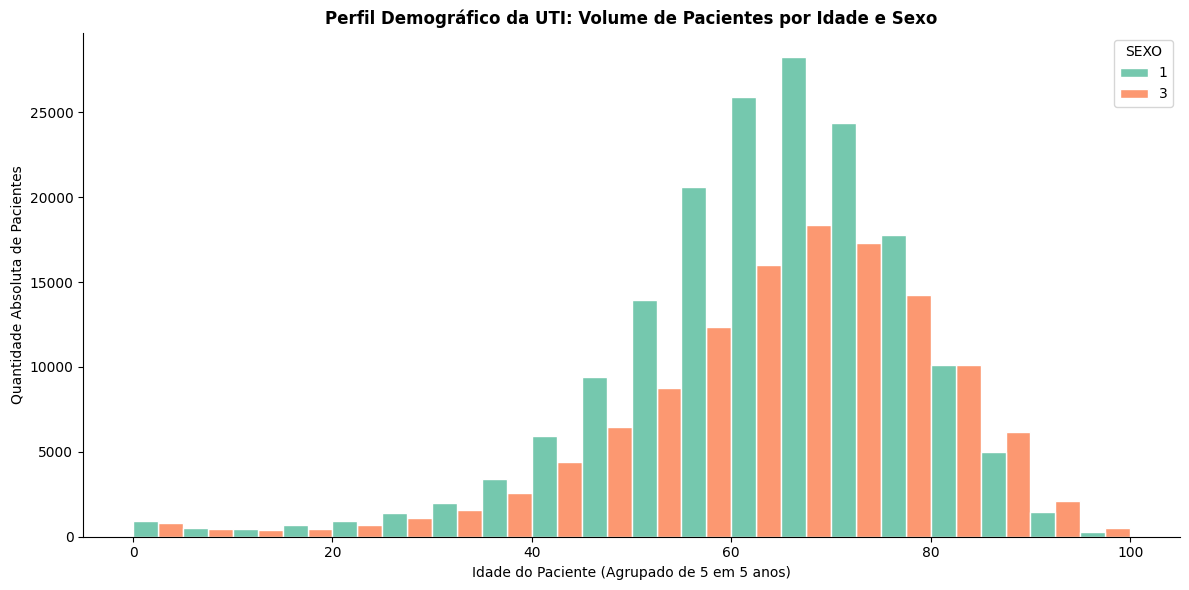

In [ ]:

df_apenas_uti = df_sus[df_sus['ALVO_UTI'] == 1]

plt.figure(figsize=(12, 6))

sns.histplot(data=df_apenas_uti,
             x='IDADE',
             hue='SEXO',
             binwidth=5,
             binrange=(0, 100),
             multiple='dodge',
             palette='Set2',
             edgecolor='white',
             alpha=0.9)

plt.title('Perfil Demográfico da UTI: Volume de Pacientes por Idade e Sexo', fontweight='bold')
plt.xlabel('Idade do Paciente (Agrupado de 5 em 5 anos)')
plt.ylabel('Quantidade Absoluta de Pacientes')

sns.despine()
plt.tight_layout()
plt.show()

- 1 = Masculino
- 3 = Feminino

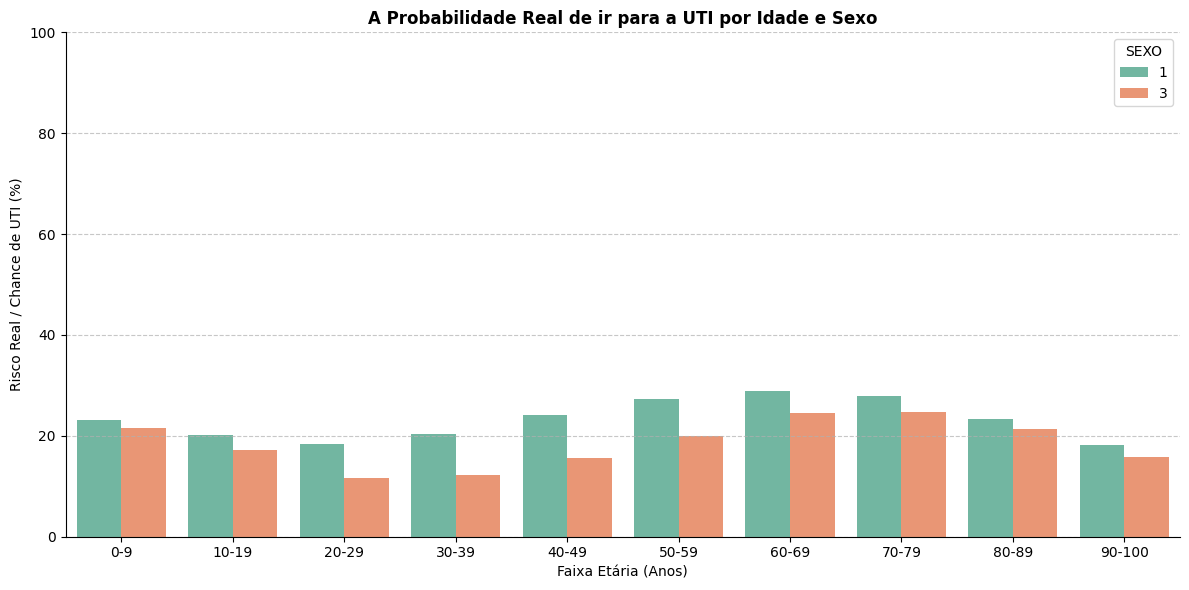

In [ ]:
import pandas as pd

# Definindo os limites de idade e rótulos para as faixas etárias
limites_idade = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 101]
rotulos = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-100']

# Criando a nova coluna de Faixa Etária
df_sus['FAIXA_ETARIA'] = pd.cut(df_sus['IDADE'], bins=limites_idade, labels=rotulos, right=False)

tabela_risco_cruzado = df_sus.groupby(['FAIXA_ETARIA', 'SEXO'], observed=False)['ALVO_UTI'].mean() * 100
tabela_risco_cruzado = tabela_risco_cruzado.reset_index()
tabela_risco_cruzado.rename(columns={'ALVO_UTI': 'TAXA_UTI_PERCENTUAL'}, inplace=True)

#(Probabilidade, não Volume)
plt.figure(figsize=(12, 6))

sns.barplot(data=tabela_risco_cruzado,
            x='FAIXA_ETARIA',
            y='TAXA_UTI_PERCENTUAL',
            hue='SEXO',
            palette='Set2')

plt.title('A Probabilidade Real de ir para a UTI por Idade e Sexo', fontweight='bold')
plt.xlabel('Faixa Etária (Anos)')
plt.ylabel('Risco Real / Chance de UTI (%)')
plt.ylim(0, 100)

plt.grid(axis='y', linestyle='--', alpha=0.7)

sns.despine()
plt.tight_layout()
plt.show()

## Tratamento da coluna SEXO

In [ ]:
# Feature Engineering - Essa faixa de idade e sexo tem mais relevância

df_sus['HOMEM_ALTO_RISCO_20_59'] = (
    (df_sus['IDADE'] >= 20) &
    (df_sus['IDADE'] <= 59) &
    (df_sus['SEXO'] == 1)
).astype(int)


display(df_sus[df_sus['HOMEM_ALTO_RISCO_20_59'] == 1][['IDADE', 'SEXO', 'HOMEM_ALTO_RISCO_20_59']].sample(5))

print(f"\nTotal de pacientes mapeados neste grupo de risco: {df_sus['HOMEM_ALTO_RISCO_20_59'].sum()}")

,IDADE,SEXO,HOMEM_ALTO_RISCO_20_59
441317,35,1,1
709865,58,1,1
1042875,57,1,1
1150303,50,1,1
446136,58,1,1



Total de pacientes mapeados neste grupo de risco: 228593


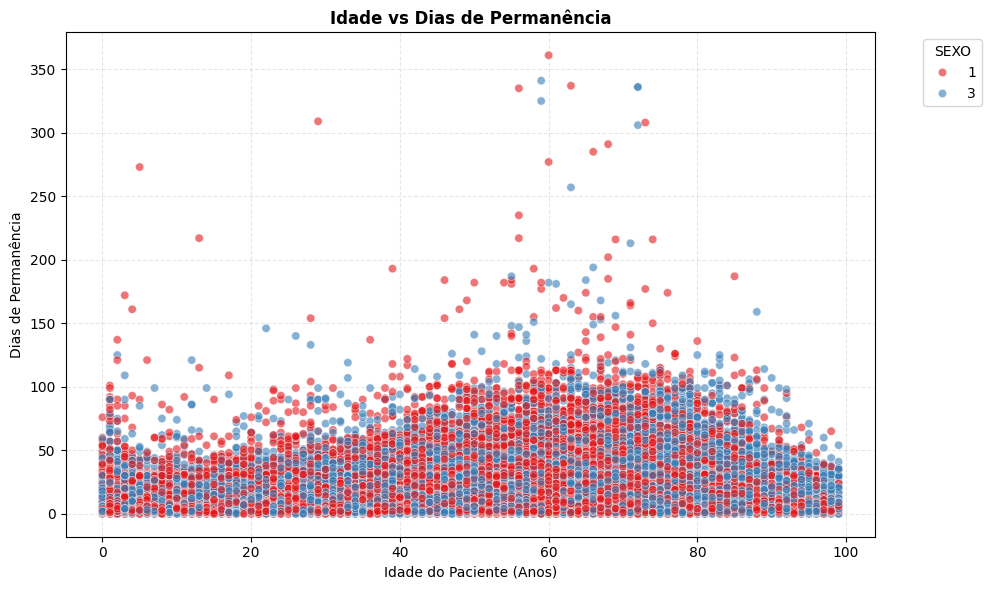

In [ ]:
plt.figure(figsize=(10, 6))


sns.scatterplot(data=df_sus,
                x='IDADE',
                y='DIAS_PERM',
                hue='SEXO',
                palette='Set1',
                alpha=0.6)

plt.title('Idade vs Dias de Permanência', fontweight='bold')
plt.xlabel('Idade do Paciente (Anos)')
plt.ylabel('Dias de Permanência')

#  legenda
plt.legend(title='SEXO', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


- 1 masculino (vermelho)
- 3 feminino (azul)

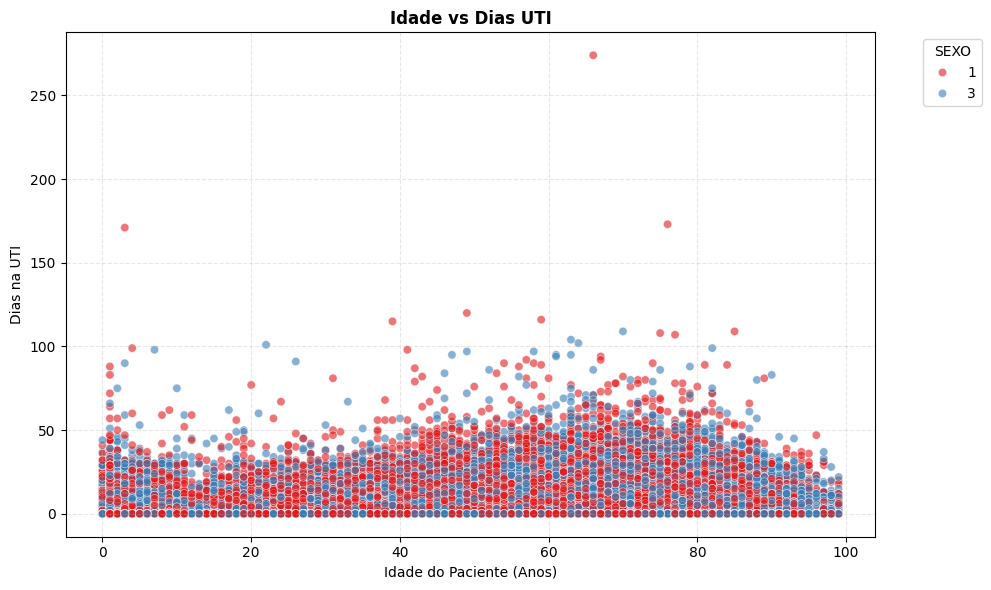

In [ ]:
plt.figure(figsize=(10, 6))


sns.scatterplot(data=df_sus,
                x='IDADE',
                y='UTI_MES_TO',
                hue='SEXO',
                palette='Set1',
                alpha=0.6)

plt.title('Idade vs Dias UTI', fontweight='bold')
plt.xlabel('Idade do Paciente (Anos)')
plt.ylabel('Dias na UTI')

#  legenda
plt.legend(title='SEXO', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- 1 masculino (vermelho)
- 3 feminino (azul)

## Coluna IDADE

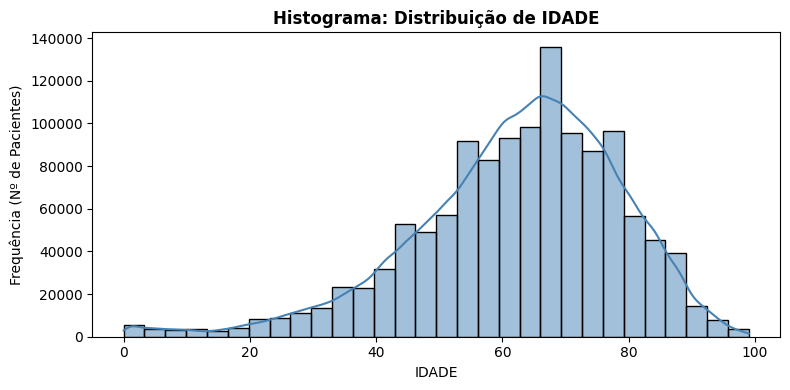

In [ ]:
coluna = 'IDADE'

plt.figure(figsize=(8, 4))

sns.histplot(x=df_sus[coluna].dropna(), kde=True, bins=30, color='steelblue')
plt.title(f'Histograma: Distribuição de {coluna}', fontweight='bold')
plt.ylabel('Frequência (Nº de Pacientes)')
plt.xlabel(coluna)
plt.tight_layout()
plt.show()

,FAIXA_ETARIA,TAXA_UTI_PERCENTUAL
0,0-9,22.348171
1,10-19,18.797136
2,20-29,14.650023
3,30-39,15.875696
4,40-49,19.665695
5,50-59,24.007477
6,60-69,27.009251
7,70-79,26.405660
8,80-89,22.300356
9,90-100,16.682650


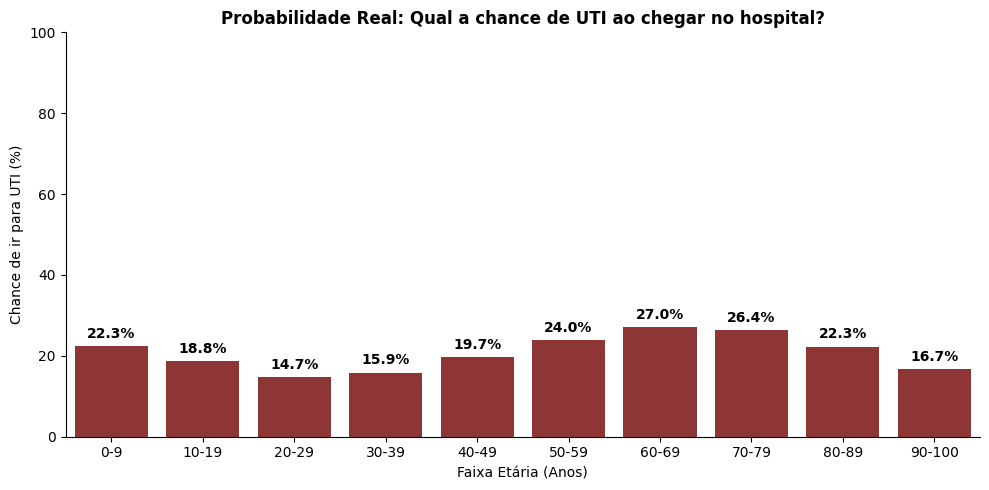

In [ ]:
# Grafico com as probabilidades por faixa etária

tabela_risco = df_sus.groupby('FAIXA_ETARIA', observed=False)['ALVO_UTI'].mean() * 100
tabela_risco = tabela_risco.reset_index()
tabela_risco.rename(columns={'ALVO_UTI': 'TAXA_UTI_PERCENTUAL'}, inplace=True)

display(tabela_risco)


plt.figure(figsize=(10, 5))

sns.barplot(data=tabela_risco, x='FAIXA_ETARIA', y='TAXA_UTI_PERCENTUAL', color='darkred', alpha=0.85)

plt.title('Probabilidade Real: Qual a chance de UTI ao chegar no hospital?', fontweight='bold')
plt.xlabel('Faixa Etária (Anos)')
plt.ylabel('Chance de ir para UTI (%)')
plt.ylim(0, 100)

for index, row in tabela_risco.iterrows():
    if pd.notna(row['TAXA_UTI_PERCENTUAL']):
        plt.text(index, row['TAXA_UTI_PERCENTUAL'] + 2, f"{row['TAXA_UTI_PERCENTUAL']:.1f}%",
                 color='black', ha="center", fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:

df_apenas_uti = df_sus[df_sus['ALVO_UTI'] == 1].copy()

contagem_uti = df_apenas_uti['FAIXA_ETARIA'].value_counts(sort=False)

tabela_perfil = (contagem_uti / contagem_uti.sum()) * 100
tabela_perfil = tabela_perfil.reset_index()
tabela_perfil.columns = ['FAIXA_ETARIA', 'PORCENTAGEM_DOS_LEITOS']

display(tabela_perfil)



,FAIXA_ETARIA,PORCENTAGEM_DOS_LEITOS
0,0-9,0.906187
1,10-19,0.660601
2,20-29,1.374211
3,30-39,3.186250
4,40-49,8.806222
5,50-59,18.656857
6,60-69,29.690132
7,70-79,24.716670
8,80-89,10.543779
9,90-100,1.459092


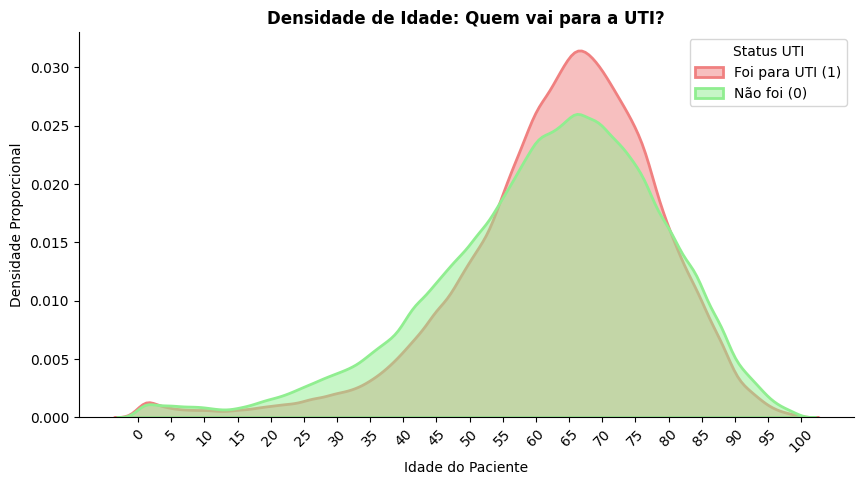

In [ ]:


plt.figure(figsize=(10, 5))


sns.kdeplot(data=df_sus,
            x='IDADE',
            hue='ALVO_UTI',
            fill=True,
            common_norm=False,
            palette={0: 'lightgreen', 1: 'lightcoral'},
            alpha=0.5,
            linewidth=2)

plt.title('Densidade de Idade: Quem vai para a UTI?', fontweight='bold')
plt.xlabel('Idade do Paciente')
plt.ylabel('Densidade Proporcional')
legend = plt.legend(title='Status UTI', labels=['Foi para UTI (1)', 'Não foi (0)'])
plt.xticks(np.arange(0, 105, 5), rotation=45)

sns.despine()
plt.show()

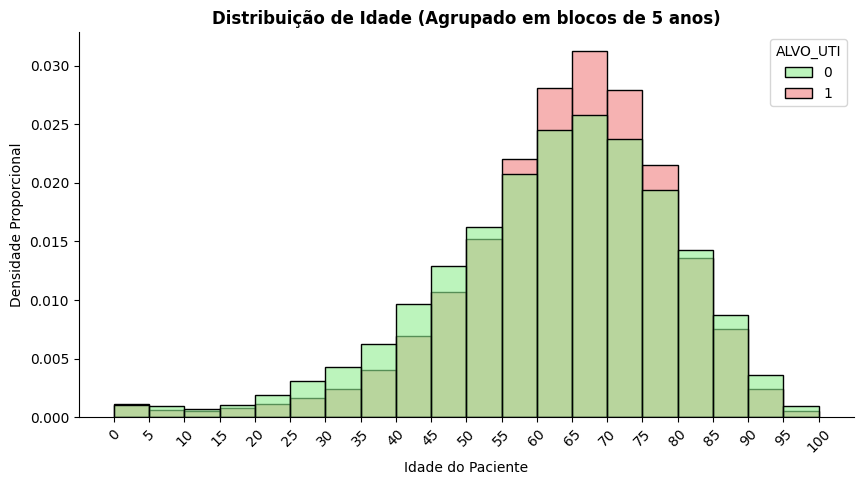

In [ ]:

plt.figure(figsize=(10, 5))


sns.histplot(data=df_sus,
             x='IDADE',
             hue='ALVO_UTI',
             binwidth=5,
             binrange=(0, 100),
             stat='density',
             common_norm=False,
             palette={0: 'lightgreen', 1: 'lightcoral'},
             alpha=0.6)

plt.title('Distribuição de Idade (Agrupado em blocos de 5 anos)', fontweight='bold')
plt.xlabel('Idade do Paciente')
plt.ylabel('Densidade Proporcional')


plt.xticks(np.arange(0, 105, 5), rotation=45)

sns.despine()
plt.show()

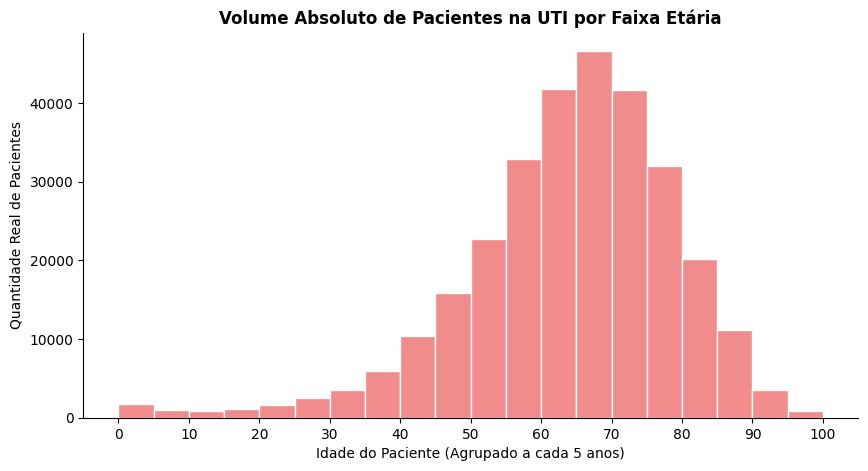

In [ ]:

df_apenas_uti = df_sus[df_sus['ALVO_UTI'] == 1]
plt.figure(figsize=(10, 5))


sns.histplot(data=df_apenas_uti,
             x='IDADE',
             binwidth=5,
             binrange=(0, 100),
             color='lightcoral',
             alpha=0.9,
             edgecolor='white')


plt.title('Volume Absoluto de Pacientes na UTI por Faixa Etária', fontweight='bold')
plt.xlabel('Idade do Paciente (Agrupado a cada 5 anos)')
plt.ylabel('Quantidade Real de Pacientes')

plt.xticks(np.arange(0, 105, 10))

sns.despine()
plt.show()

### Tratamento da Coluna Idade

In [ ]:
# Criando mais uma feature - 1 = idade de risco crítico, 0 = Fora da faixa

df_sus['IDADE_RISCO_CRITICO'] = df_sus['IDADE'].apply(lambda x: 1 if 58 <= x <= 76 else 0)

## Coluna RACA/COR

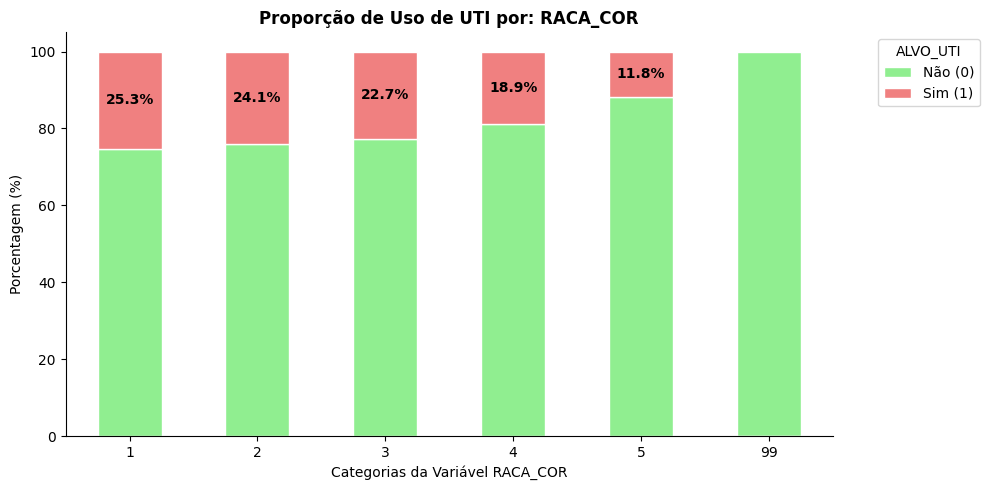

--------------------------------------------------------------------------------


In [ ]:
variaveis_cat = ['RACA_COR']

for var in variaveis_cat:

    crosstab_prop = pd.crosstab(df_sus[var], df_sus['ALVO_UTI'], normalize='index') * 100


    ax = crosstab_prop.plot(kind='bar', stacked=True, figsize=(10, 5),
                            color=['lightgreen', 'lightcoral'], edgecolor='white')

    plt.title(f'Proporção de Uso de UTI por: {var}', fontweight='bold')
    plt.ylabel('Porcentagem (%)')
    plt.xlabel(f'Categorias da Variável {var}')

    plt.legend(title='ALVO_UTI', labels=['Não (0)', 'Sim (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')


    plt.xticks(rotation=0)
    sns.despine()


    for p in ax.patches:
        largura, altura = p.get_width(), p.get_height()
        x, y = p.get_xy()

        if altura > 0 and y > 0:
            ax.annotate(f'{altura:.1f}%',
                        (x + largura/2, y + altura/2),
                        ha='center', va='center', color='black', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.show()
    print("-" * 80)

01 = Branca
02 = Preta
03 = Parda
04 = Amarela
05 = Indígena
99 = Sem informação

## Coluna Carater da Internação (CAR_INT)

01 = Eletiva (agendada)

02 = Urgência / Emergência

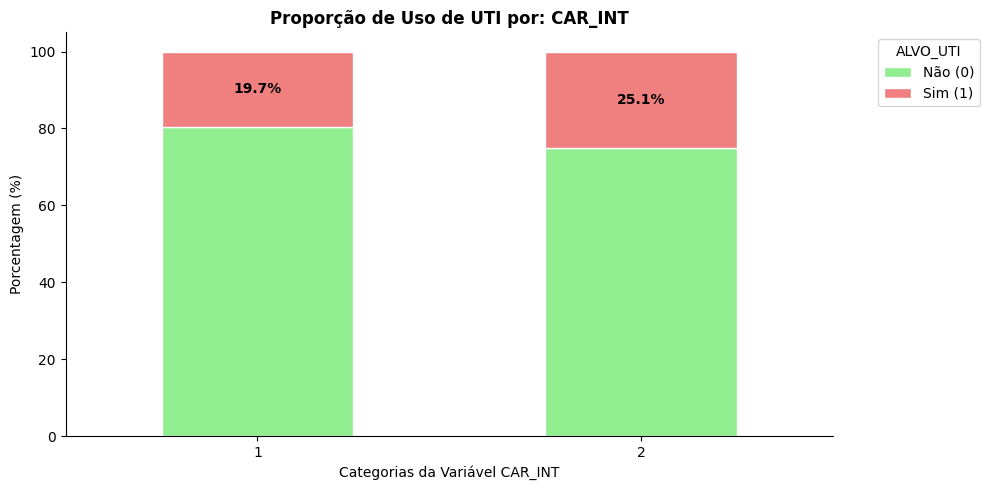

--------------------------------------------------------------------------------


In [ ]:
variaveis_cat = ['CAR_INT']

for var in variaveis_cat:
    crosstab_prop = pd.crosstab(df_sus[var], df_sus['ALVO_UTI'], normalize='index') * 100

    ax = crosstab_prop.plot(kind='bar', stacked=True, figsize=(10, 5),
                            color=['lightgreen', 'lightcoral'], edgecolor='white')

    plt.title(f'Proporção de Uso de UTI por: {var}', fontweight='bold')
    plt.ylabel('Porcentagem (%)')
    plt.xlabel(f'Categorias da Variável {var}')

    plt.legend(title='ALVO_UTI', labels=['Não (0)', 'Sim (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')


    plt.xticks(rotation=0)
    sns.despine()

    for p in ax.patches:
        largura, altura = p.get_width(), p.get_height()
        x, y = p.get_xy()
        if altura > 0 and y > 0:
            ax.annotate(f'{altura:.1f}%',
                        (x + largura/2, y + altura/2),
                        ha='center', va='center', color='black', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.show()
    print("-" * 80)


01 = Eletiva (agendada)

02 = Urgência / Emergência

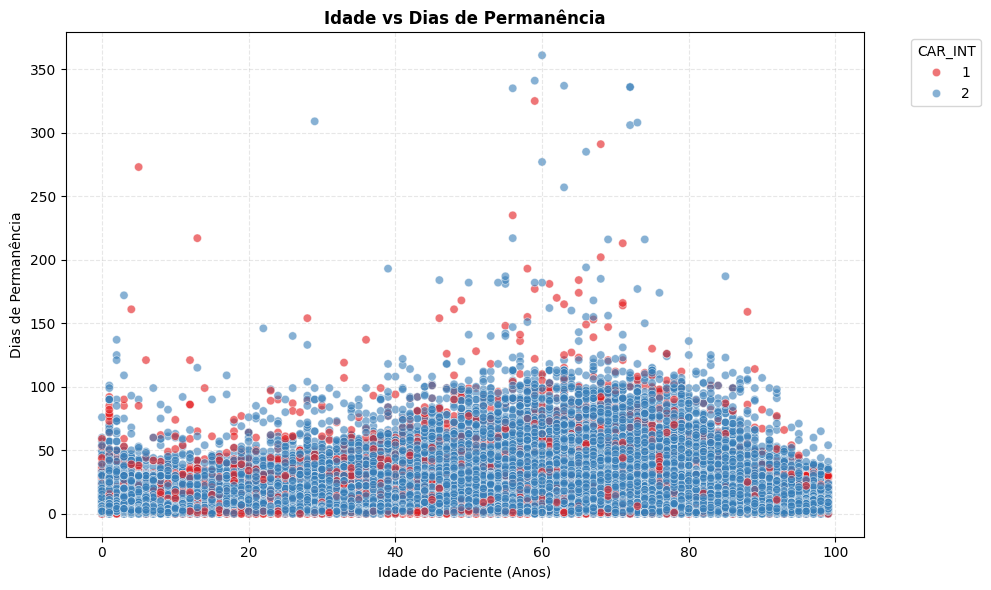

In [ ]:
plt.figure(figsize=(10, 6))


sns.scatterplot(data=df_sus,
                x='IDADE',
                y='DIAS_PERM',
                hue='CAR_INT',
                palette='Set1',
                alpha=0.6)

plt.title('Idade vs Dias de Permanência', fontweight='bold')
plt.xlabel('Idade do Paciente (Anos)')
plt.ylabel('Dias de Permanência')

#  legenda
plt.legend(title='CAR_INT', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


01 = Eletiva (agendada)

02 = Urgência / Emergência

## Coluna Dias de Permanência (DIAS_PERM)

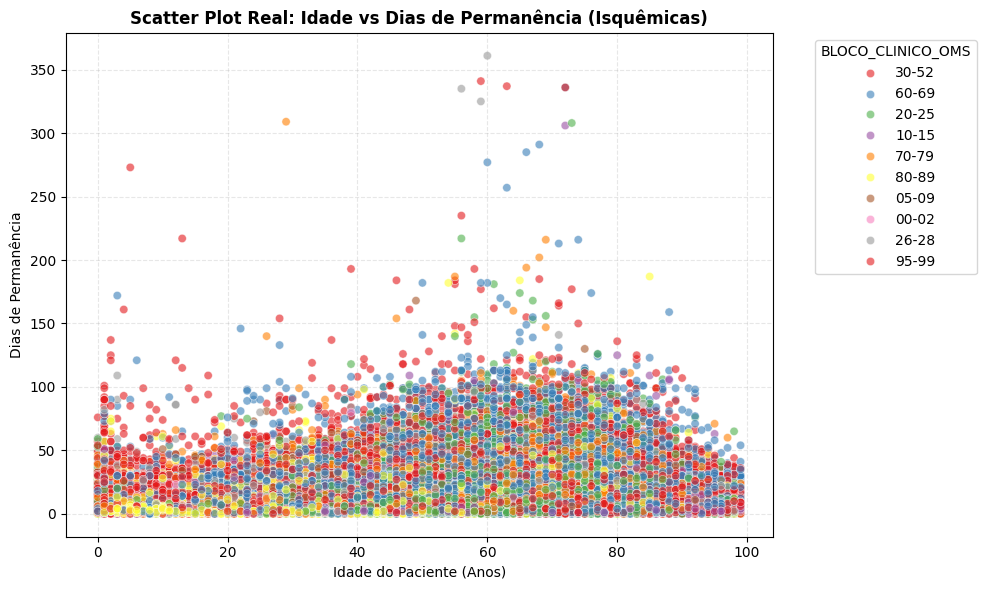

In [ ]:
plt.figure(figsize=(10, 6))


sns.scatterplot(data=df_sus,
                x='IDADE',
                y='DIAS_PERM',
                hue='BLOCO_CLINICO_OMS',
                palette='Set1',
                alpha=0.6)

plt.title('Scatter Plot Real: Idade vs Dias de Permanência (Isquêmicas)', fontweight='bold')
plt.xlabel('Idade do Paciente (Anos)')
plt.ylabel('Dias de Permanência')

#  legenda
plt.legend(title='BLOCO_CLINICO_OMS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


- 00-02 	Febre Reumática Aguda
- 05-09 	Doenças Cardíacas Reumáticas Crônicas
- 10-15 	Doenças Hipertensivas
- 20-25 	Doenças Isquêmicas (Ex: Infarto do Miocárdio)
- 26-28 	Doenças Cardiopulmonares
- 30-52 	Outras Doenças do Coração (Ex: Insuficiência Cardíaca)
- 60-69 	Doenças Cerebrovasculares (Ex: AVC - Acidente Vascular Cerebral)
- 70-79 	Doenças das Artérias e Capilares
- 80-89 	Doenças das Veias e Vasos Linfáticos
- 95-99 	Outros Transtornos Circulatórios

/tmp/ipykernel_52193/1145256627.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_plot, x='Status UTI', order=['Não usou UTI (0)', 'Usou UTI (>0)'], palette=['lightgreen', 'lightcoral'])


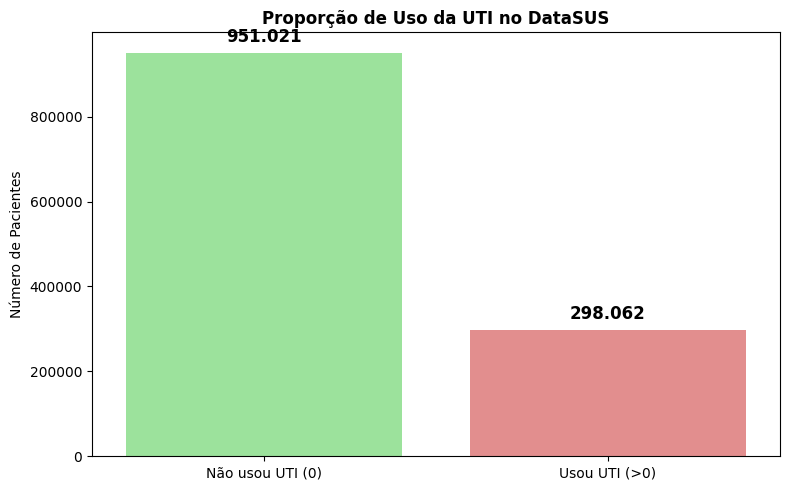

In [ ]:
qtd_zeros = (df_sus['UTI_MES_TO'] == 0).sum()
qtd_maior_que_zero = (df_sus['UTI_MES_TO'] > 0).sum()
qtd_total = len(df_sus)

perc_zeros = (qtd_zeros / qtd_total) * 100
perc_uti = (qtd_maior_que_zero / qtd_total) * 100


df_plot = df_sus.copy()
df_plot['Status UTI'] = df_plot['UTI_MES_TO'].apply(lambda x: 'Não usou UTI (0)' if x == 0 else 'Usou UTI (>0)')


plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_plot, x='Status UTI', order=['Não usou UTI (0)', 'Usou UTI (>0)'], palette=['lightgreen', 'lightcoral'])

plt.title('Proporção de Uso da UTI no DataSUS', fontweight='bold')
plt.ylabel('Número de Pacientes')
plt.xlabel('')


for p in ax.patches:
    altura = int(p.get_height())
    ax.annotate(f'{altura:,}'.replace(',', '.'),
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


# RESUMO GERAL - Após o tratamento das Colunas

In [ ]:
df_sus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1249083 entries, 0 to 1249082
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype   
---  ------                  --------------    -----   
 0   SEXO                    1249083 non-null  int64   
 1   IDADE                   1249083 non-null  int64   
 2   RACA_COR                1249083 non-null  int64   
 3   CAR_INT                 1249083 non-null  int64   
 4   COMPLEX                 1249083 non-null  int64   
 5   DIAS_PERM               1249083 non-null  int64   
 6   UTI_MES_TO              1249083 non-null  int64   
 7   MARCA_UTI               1249083 non-null  int64   
 8   DIAG_PRINC              1249083 non-null  object  
 9   PROC_REA                1249083 non-null  int64   
 10  GRUPO_PROC_COD          1249083 non-null  object  
 11  CID_3_DIGITOS           1249083 non-null  object  
 12  BLOCO_CLINICO_OMS       1249083 non-null  object  
 13  ALVO_UTI                1249083 non-null  

In [ ]:
df_sus = dados


info_colunas = []

for coluna in df_sus.columns:

    valores_unicos = df_sus[coluna].dropna().unique()

    info_colunas.append({
        'Nome da Coluna': coluna,
        'Tipo de Dado': df_sus[coluna].dtype,
        'Qtd Valores Únicos': len(valores_unicos),
        'Amostra de Valores': list(valores_unicos)[:5],
        'Qtd Nulos': df_sus[coluna].isnull().sum()
    })


df_dicionario = pd.DataFrame(info_colunas)


display(df_dicionario)

,Nome da Coluna,Tipo de Dado,Qtd Valores Únicos,Amostra de Valores,Qtd Nulos
0,SEXO,int64,2,"[1, 3]",0
1,IDADE,int64,100,"[85, 73, 70, 81, 48]",0
2,RACA_COR,int64,6,"[3, 4, 5, 1, 2]",0
3,CAR_INT,int64,2,"[2, 1]",0
4,COMPLEX,int64,2,"[2, 3]",0
5,DIAS_PERM,int64,187,"[8, 5, 1, 12, 11]",0
6,UTI_MES_TO,int64,109,"[0, 23, 39, 4, 6]",0
7,MARCA_UTI,int64,14,"[0, 75, 81, 78, 86]",0
8,DIAG_PRINC,object,455,"[I500, I64 , I219, I638, I472]",0
9,PROC_REA,int64,767,"[303060212, 303040149, 301060088, 303060026, 3...",0


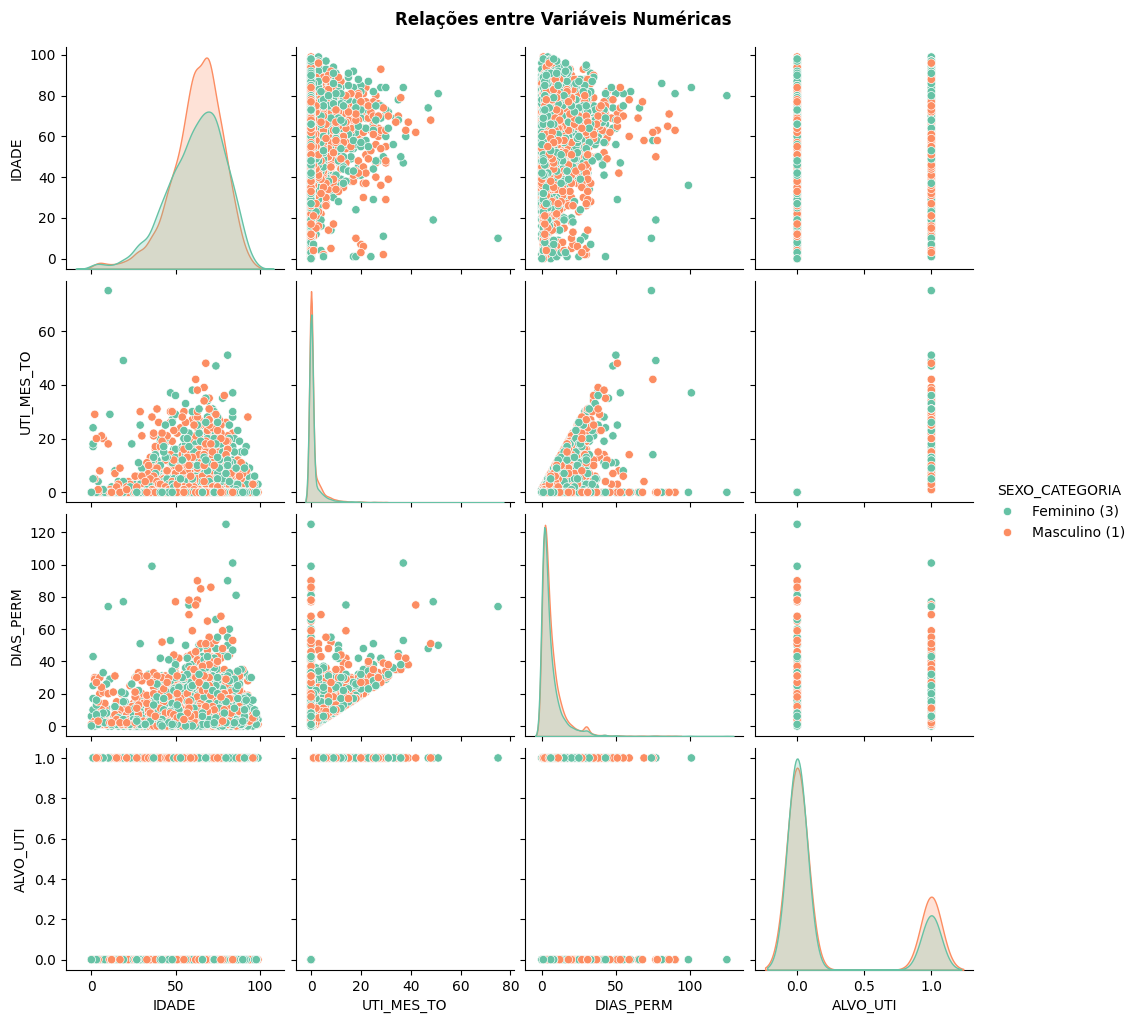

In [ ]:
colunas_grafico = ['IDADE', 'UTI_MES_TO', 'DIAS_PERM', 'ALVO_UTI', 'SEXO']
df_amostra = df_sus[colunas_grafico].dropna().sample(n=10000,random_state=42)

df_amostra['SEXO_CATEGORIA'] = df_amostra['SEXO'].map({1: 'Masculino (1)', 3: 'Feminino (3)'})

sns.pairplot(df_amostra,
             vars=['IDADE', 'UTI_MES_TO', 'DIAS_PERM', 'ALVO_UTI'],
             hue='SEXO_CATEGORIA',
             palette='Set2')

plt.suptitle('Relações entre Variáveis Numéricas', y=1.02, fontweight='bold')
plt.show()

# PIPELINE DE PRÉ-PROCESSAMENTO

### Separação dos dados: Treino e Teste

**Separando** os dados de **Treino** e **Teste** primeiro, a fim de que não haja Data Leakege (vazamento de dados) ao realizar a Padronização dos dados e a transformação de variáveis categóricas para número.

In [ ]:

colunas = ['IDADE','SEXO','RACA_COR','CAR_INT','BLOCO_CLINICO_OMS','IDADE_RISCO_CRITICO','HOMEM_ALTO_RISCO_20_59']

X = df_sus[colunas].copy()
y = df_sus['ALVO_UTI']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Padronização de dados numéricos e a transformação de variáveis categóricas para número.

- Para padronização usamos o StandardScaler que lida melhor com outliers.
- Para Tranformação das variáveis categóricas usamos OneHotEncoder para colunas nas quais os valores não possuem ordem de grandeza.


Optamos por não utilizar o OrdinalEncoder na variável CAR_INT (Caráter de Internação) pois trata-se de uma variável estritamente Nominal, e não Ordinal. Embora nosso recorte atual de dados apresente apenas duas categorias (01 - Eletivo e 02 - Urgência), o dicionário oficial do SUS abrange cenários sem qualquer relação de grandeza matemática entre si, como:

    03: Acidente de trabalho

    04: Acidente no trajeto do trabalho

    05: Outros acidentes de trânsito

    06: Outros tipos de lesões/envenenamentos

Forçar uma codificação ordinal criaria uma falsa hierarquia (sugerindo que o código 06 é "maior" ou "mais grave" que o 02), corrompendo a interpretação do algoritmo. Mantivemos o OneHotEncoder para garantir a integridade do modelo se posteriormente for usado em novos dados em produção.

In [ ]:
colunas_numericas = ['IDADE']
colunas_categoricas = ['SEXO', 'RACA_COR', 'CAR_INT', 'BLOCO_CLINICO_OMS']
colunas_binarias_prontas = ['IDADE_RISCO_CRITICO', 'HOMEM_ALTO_RISCO_20_59']

# Padronização dos dados numericos
escalonador_numerico = StandardScaler()

# tratando colunas categoricas
codificador_categorico = OneHotEncoder(handle_unknown='ignore', sparse_output=False)


In [ ]:
pre_processador = ColumnTransformer(
    transformers=[
        ('num', escalonador_numerico, colunas_numericas),
        ('cat', codificador_categorico, colunas_categoricas),
        ('bin', 'passthrough', colunas_binarias_prontas)
    ]
)

# Fit_transform no Treino
X_treino_processado = pre_processador.fit_transform(X_treino)

# transform no Teste
X_teste_processado = pre_processador.transform(X_teste)

In [ ]:
# Visualizar o tratamento dos dados
nomes_das_colunas = pre_processador.get_feature_names_out()

X_treino_df = pd.DataFrame(X_treino_processado, columns=nomes_das_colunas)

display(X_treino_df.head())

,num__IDADE,cat__SEXO_1,cat__SEXO_3,cat__RACA_COR_1,cat__RACA_COR_2,cat__RACA_COR_3,cat__RACA_COR_4,cat__RACA_COR_5,cat__RACA_COR_99,cat__CAR_INT_1,...,cat__BLOCO_CLINICO_OMS_10-15,cat__BLOCO_CLINICO_OMS_20-25,cat__BLOCO_CLINICO_OMS_26-28,cat__BLOCO_CLINICO_OMS_30-52,cat__BLOCO_CLINICO_OMS_60-69,cat__BLOCO_CLINICO_OMS_70-79,cat__BLOCO_CLINICO_OMS_80-89,cat__BLOCO_CLINICO_OMS_95-99,bin__IDADE_RISCO_CRITICO,bin__HOMEM_ALTO_RISCO_20_59
0,-1.475350,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-0.260067,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,0.529867,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.623622,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.469103,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# ANALISANDO MODELOS

Tendo em vista que o DataSet tem mais de 1 milhão de linhas, alguns algoritmos não são indicados como o KNN e SVC.

### Random Forest

In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=40,          # 40 árvores
    class_weight='balanced',  # Pesa os erros. Errar a classe 1 (UTI) custa mais
    max_depth=10,             # Trava o crescimento da árvore em 10
    random_state=42,
    n_jobs=-1                 # usar todos os núcleos possíveis
)
modelo_rf.fit(X_treino_processado, y_treino)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=40,
                       n_jobs=-1, random_state=42)

#### Analisando resultados do Random Forest

--- RELATÓRIO DE MÉTRICAS ---
              precision    recall  f1-score   support

           0       0.87      0.55      0.67    190205
           1       0.34      0.74      0.47     59612

    accuracy                           0.60    249817
   macro avg       0.61      0.64      0.57    249817
weighted avg       0.74      0.60      0.62    249817



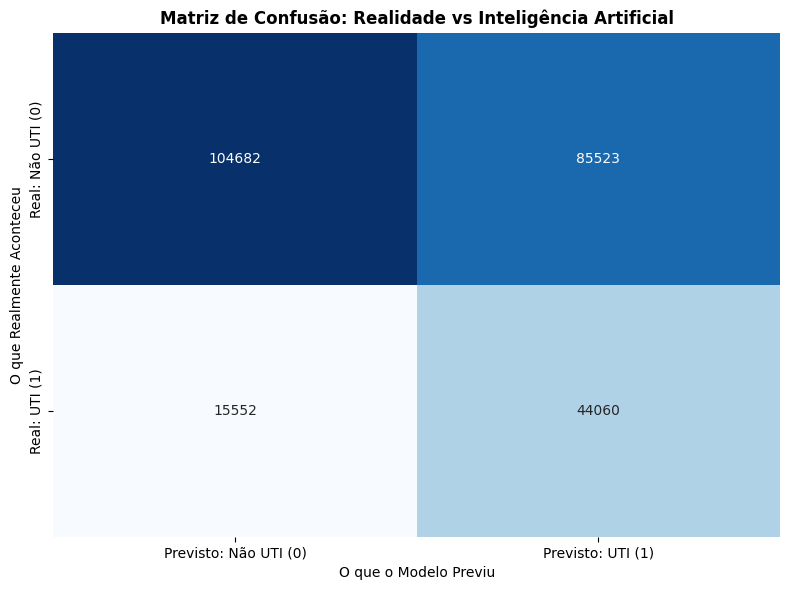

In [ ]:

previsoes = modelo_rf.predict(X_teste_processado)

# 1. O Relatório de Classificação
print("--- RELATÓRIO DE MÉTRICAS ---")
print(classification_report(y_teste, previsoes))

# 2. Matriz de Confusão
matriz = confusion_matrix(y_teste, previsoes)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Previsto: Não UTI (0)', 'Previsto: UTI (1)'],
            yticklabels=['Real: Não UTI (0)', 'Real: UTI (1)'])

plt.title('Matriz de Confusão: Realidade vs Inteligência Artificial', fontweight='bold')
plt.xlabel('O que o Modelo Previu')
plt.ylabel('O que Realmente Aconteceu')
plt.tight_layout()
plt.show()

Resultado da matrix de confusão:

Os **Acertos** do Modelo:
- 114.862 não precisavam de UTI
- 44.060 precisavam de UTI

Os **Erros** do Modelo:
- 85.523 não precisavam de UTI
- 15.552 precisavam de UTI

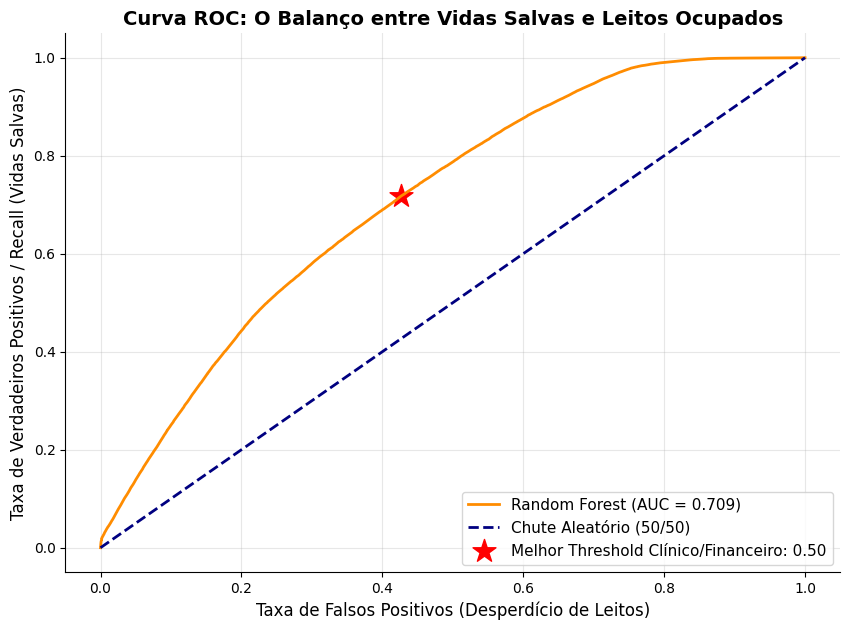

In [ ]:

# Curva ROC

# porcentagem de risco que ele calculou para cada paciente
probabilidades_uti = modelo_rf.predict_proba(X_teste_processado)[:, 1]


fpr, tpr, thresholds = roc_curve(y_teste, probabilidades_uti)
#tpr (True Positive Rate): O nosso Recall. Quantas vidas salvamos na simulação.
#fpr (False Positive Rate): O custo. alarmes falsos.

auc = roc_auc_score(y_teste, probabilidades_uti)


indice_melhor_ponto = np.argmax(tpr - fpr)
melhor_threshold = thresholds[indice_melhor_ponto]


plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chute Aleatório (50/50)')


plt.scatter(fpr[indice_melhor_ponto], tpr[indice_melhor_ponto],
            marker='*', color='red', s=300,
            label=f'Melhor Threshold Clínico/Financeiro: {melhor_threshold:.2f}')


plt.title('Curva ROC: O Balanço entre Vidas Salvas e Leitos Ocupados', fontweight='bold', fontsize=14)
plt.xlabel('Taxa de Falsos Positivos (Desperdício de Leitos)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos / Recall (Vidas Salvas)', fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
sns.despine()

plt.show()

## Regressão Logística



In [ ]:
from sklearn.linear_model import LogisticRegression

# Testando com Regressão Logistica
modelo_logistico = LogisticRegression(
    max_iter=1000,            #  CONVERGÊNCIA: mais tempo/passos para resolver a equação matemática complexa.
    class_weight='balanced',  #  mesmo peso para casos de UTI (1) e casos comuns (0).
    solver='lbfgs',           # O algoritmo matemático por trás.
    random_state=42,
    n_jobs=-1
)

modelo_logistico.fit(X_treino_processado, y_treino)


LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

In [ ]:

previsoes_logisticas = modelo_logistico.predict(X_teste_processado)

# .predict_proba() traz a porcentagem exata (0.00 a 1.00) calculada pela curva sigmoide
probabilidades = modelo_logistico.predict_proba(X_teste_processado)

print("Exemplo dos 5 primeiros pacientes do seu cofre de Teste:")
for i in range(5):
    prob_uti = probabilidades[i][1] * 100
    decisao = previsoes_logisticas[i]
    print(f"Paciente {i+1}: Chance de UTI = {prob_uti:.1f}% -> Decisão Final: {decisao}")

Exemplo dos 5 primeiros pacientes do seu cofre de Teste:
Paciente 1: Chance de UTI = 5.0% -> Decisão Final: 0
Paciente 2: Chance de UTI = 51.2% -> Decisão Final: 1
Paciente 3: Chance de UTI = 39.0% -> Decisão Final: 0
Paciente 4: Chance de UTI = 52.2% -> Decisão Final: 1
Paciente 5: Chance de UTI = 66.1% -> Decisão Final: 1


### Analisando resultados da Regressão Logística

--- RELATÓRIO DE MÉTRICAS (REGRESSÃO LOGÍSTICA) ---
              precision    recall  f1-score   support

           0       0.86      0.58      0.69    190205
           1       0.34      0.69      0.46     59612

    accuracy                           0.61    249817
   macro avg       0.60      0.64      0.58    249817
weighted avg       0.73      0.61      0.64    249817



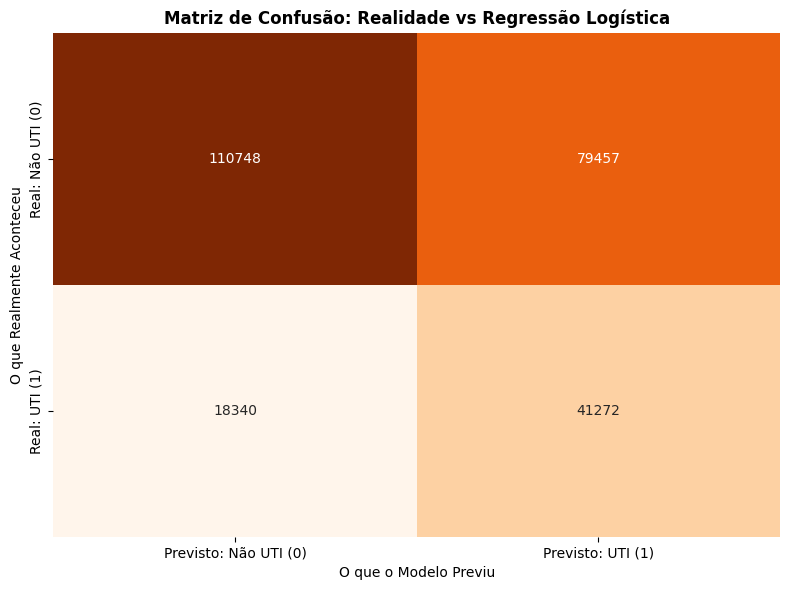

In [ ]:
print("--- RELATÓRIO DE MÉTRICAS (REGRESSÃO LOGÍSTICA) ---")
print(classification_report(y_teste, previsoes_logisticas))

matriz_log = confusion_matrix(y_teste, previsoes_logisticas)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_log, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Previsto: Não UTI (0)', 'Previsto: UTI (1)'],
            yticklabels=['Real: Não UTI (0)', 'Real: UTI (1)'])

plt.title('Matriz de Confusão: Realidade vs Regressão Logística', fontweight='bold')
plt.xlabel('O que o Modelo Previu')
plt.ylabel('O que Realmente Aconteceu')
plt.tight_layout()
plt.show()

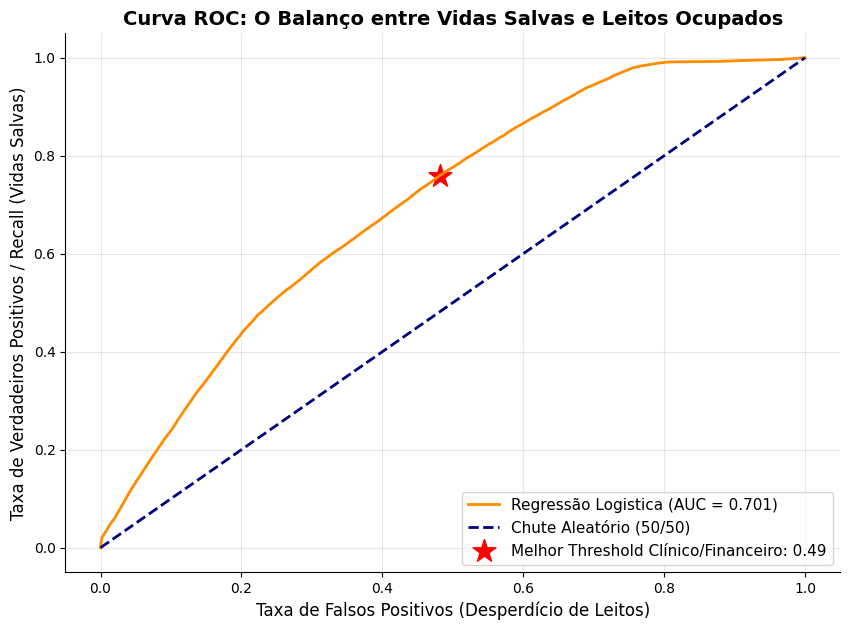

In [ ]:

# Curva ROC

# porcentagem de risco que ele calculou para cada paciente
probabilidades_uti = modelo_logistico.predict_proba(X_teste_processado)[:, 1]


fpr, tpr, thresholds = roc_curve(y_teste, probabilidades_uti)
#tpr (True Positive Rate): O nosso Recall. Quantas vidas salvamos na simulação.
#fpr (False Positive Rate): O custo. alarmes falsos.

auc = roc_auc_score(y_teste, probabilidades_uti)


indice_melhor_ponto = np.argmax(tpr - fpr)
melhor_threshold = thresholds[indice_melhor_ponto]


plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Regressão Logistica (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chute Aleatório (50/50)')


plt.scatter(fpr[indice_melhor_ponto], tpr[indice_melhor_ponto],
            marker='*', color='red', s=300,
            label=f'Melhor Threshold Clínico/Financeiro: {melhor_threshold:.2f}')


plt.title('Curva ROC: O Balanço entre Vidas Salvas e Leitos Ocupados', fontweight='bold', fontsize=14)
plt.xlabel('Taxa de Falsos Positivos (Desperdício de Leitos)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos / Recall (Vidas Salvas)', fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
sns.despine()

plt.show()

Ajustando a Régua de Decisão (Threshold) para 75%...

--- NOVO RELATÓRIO DE MÉTRICAS (RÉGUA DE 75%) ---
              precision    recall  f1-score   support

           0       0.82      0.80      0.81    190205
           1       0.41      0.45      0.42     59612

    accuracy                           0.71    249817
   macro avg       0.61      0.62      0.62    249817
weighted avg       0.72      0.71      0.72    249817



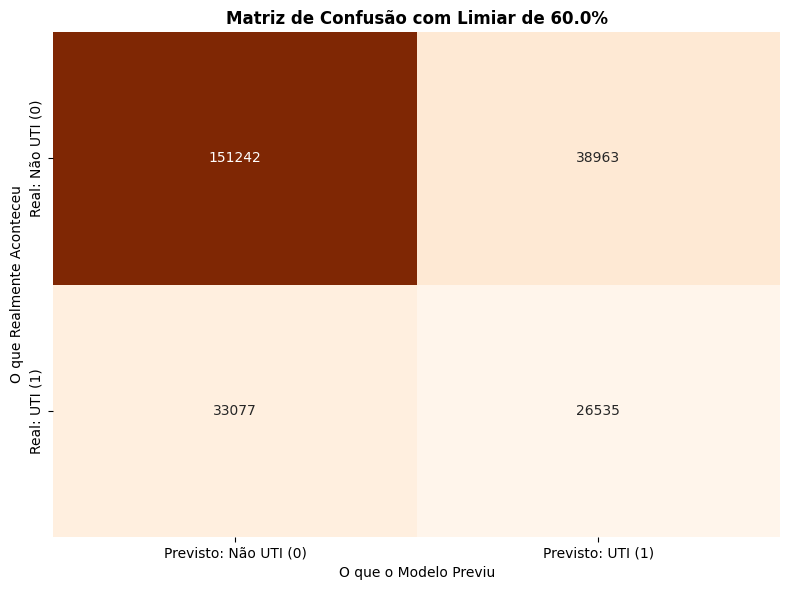

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Ajustando a Régua de Decisão (Threshold) para 75%...\n")

# 1. Pegamos apenas a coluna 1 (A probabilidade bruta de ir para a UTI, de 0.00 a 1.00)
probabilidades_uti = modelo_logistico.predict_proba(X_teste_processado)[:, 1]

# 2. CRIAMOS A NOSSA NOVA REGRA (O modelo só apita se a chance for maior ou igual a 75%)
novo_limiar = 0.60
previsoes_rigorosas = (probabilidades_uti >= novo_limiar).astype(int)

# 3. Imprimindo o novo relatório
print("--- NOVO RELATÓRIO DE MÉTRICAS (RÉGUA DE 75%) ---")
print(classification_report(y_teste, previsoes_rigorosas))

# 4. Desenhando a nova Matriz para vermos os Alarmes Falsos caindo
matriz_rigorosa = confusion_matrix(y_teste, previsoes_rigorosas)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_rigorosa, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Previsto: Não UTI (0)', 'Previsto: UTI (1)'],
            yticklabels=['Real: Não UTI (0)', 'Real: UTI (1)'])

plt.title(f'Matriz de Confusão com Limiar de {novo_limiar*100}%', fontweight='bold')
plt.xlabel('O que o Modelo Previu')
plt.ylabel('O que Realmente Aconteceu')
plt.tight_layout()
plt.show()

#ANALIZANDO OS RESULTADOS